# Part 1: Data Preparation and Exploratory Data Analysis

##  Import Required Libraries

This cell imports all the libraries required for data preprocessing, visualization, time series analysis, machine learning, deep learning, and model evaluation.

In [1]:

# Import Required Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Forecasting models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


## Load and Inspect the Dataset

This cell loads the Open Power System Data (OPSD) dataset and displays its structure, column names, and basic information for initial inspection.

In [9]:
#  Load and Inspect the Dataset
# Load the dataset
df = pd.read_csv(
    r"C:\Users\maddi\Downloads\time_series_60min_singleindex.csv"
)

# Display basic information
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (50401, 300)

First 5 Rows:


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN



Column Names:
['utc_timestamp', 'cet_cest_timestamp', 'AT_load_actual_entsoe_transparency', 'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead', 'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual', 'BE_wind_onshore_generation_actual', 'BG_load_actual_entsoe_transparency', 'BG_load_forecast_entsoe_transparency', 'BG_solar_generation_actual', 'BG_wind_onshore_generation_actual', 'CH_load_actual_entsoe_transparency', 'CH_load_forecast_entsoe_transparency', 'CH_solar_capacity', 'CH_solar_generation_actual', 'CH_wind_onshore_capacity', 'CH_wind_onshore_generation_actual', 'CY_load_actual_entsoe_transparency', 'CY_load_forecast_entsoe_transparency', 'CY_wind_onshore_generation_actual', 'CZ_load_actual_entsoe_transparency', 'CZ_load_forecast_entsoe_transparency', 'CZ_solar_generation_actual', 'CZ_

## Select German Electricity Demand Data

This section identifies and displays the columns related to Germany's electricity demand, which are used for the forecasting analysis.

In [10]:
# Select German Electricity Demand Data
# Display all columns containing 'DE'
de_columns = [col for col in df.columns if "DE" in col]

print("German-related columns:")
for col in de_columns:
    print(col)

German-related columns:
DE_load_actual_entsoe_transparency
DE_load_forecast_entsoe_transparency
DE_solar_capacity
DE_solar_generation_actual
DE_solar_profile
DE_wind_capacity
DE_wind_generation_actual
DE_wind_profile
DE_wind_offshore_capacity
DE_wind_offshore_generation_actual
DE_wind_offshore_profile
DE_wind_onshore_capacity
DE_wind_onshore_generation_actual
DE_wind_onshore_profile
DE_50hertz_load_actual_entsoe_transparency
DE_50hertz_load_forecast_entsoe_transparency
DE_50hertz_solar_generation_actual
DE_50hertz_wind_generation_actual
DE_50hertz_wind_offshore_generation_actual
DE_50hertz_wind_onshore_generation_actual
DE_LU_load_actual_entsoe_transparency
DE_LU_load_forecast_entsoe_transparency
DE_LU_price_day_ahead
DE_LU_solar_generation_actual
DE_LU_wind_generation_actual
DE_LU_wind_offshore_generation_actual
DE_LU_wind_onshore_generation_actual
DE_amprion_load_actual_entsoe_transparency
DE_amprion_load_forecast_entsoe_transparency
DE_amprion_solar_generation_actual
DE_amprion_wind

## Create Germany Electricity Demand Dataset

This section extracts the German electricity demand data, renames the columns, and prepares the dataset for further analysis and forecasting.

In [11]:
# Create Germany Electricity Demand Dataset
# Keep only the required columns

germany_df = df[['utc_timestamp', 'DE_load_actual_entsoe_transparency']].copy()

# Rename columns for simplicity
germany_df.columns = ['timestamp', 'load']

# Convert timestamp to datetime
germany_df['timestamp'] = pd.to_datetime(germany_df['timestamp'])

# Sort values
germany_df = germany_df.sort_values('timestamp')

# Reset index
germany_df.reset_index(drop=True, inplace=True)

# Display information
print("Dataset Shape:", germany_df.shape)

print("\nMissing Values:")
print(germany_df.isnull().sum())

display(germany_df.head())

Dataset Shape: (50401, 2)

Missing Values:
timestamp    0
load         1
dtype: int64


,timestamp,load
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,41151.0
2,2015-01-01 01:00:00+00:00,40135.0
3,2015-01-01 02:00:00+00:00,39106.0
4,2015-01-01 03:00:00+00:00,38765.0


## Data Cleaning

This section removes missing values from the dataset and ensures the data is clean and ready for analysis and modelling.

In [12]:
# Data Cleaning
# Remove missing values

germany_df.dropna(inplace=True)

# Reset index
germany_df.reset_index(drop=True, inplace=True)

# Check missing values again
print("Missing Values After Cleaning:")
print(germany_df.isnull().sum())

print("\nDataset Shape After Cleaning:")
print(germany_df.shape)

display(germany_df.head())

Missing Values After Cleaning:
timestamp    0
load         0
dtype: int64

Dataset Shape After Cleaning:
(50400, 2)


,timestamp,load
0,2015-01-01 00:00:00+00:00,41151.0
1,2015-01-01 01:00:00+00:00,40135.0
2,2015-01-01 02:00:00+00:00,39106.0
3,2015-01-01 03:00:00+00:00,38765.0
4,2015-01-01 04:00:00+00:00,38941.0


## Filter the Required Time Period

This section filters the dataset to include data from January 2015 to October 2020, matching the period required for the analysis.

In [13]:
# Filter Data (January 2015 - October 2020)
# Keep only data from 1 January 2015 onwards

germany_df = germany_df[germany_df['timestamp'] >= '2015-01-01']

# Reset index
germany_df.reset_index(drop=True, inplace=True)

print("Dataset Shape:", germany_df.shape)

print("\nStart Date:", germany_df['timestamp'].min())
print("End Date:", germany_df['timestamp'].max())

Dataset Shape: (50400, 2)

Start Date: 2015-01-01 00:00:00+00:00
End Date: 2020-09-30 23:00:00+00:00


## Create Hourly, Daily and Weekly Datasets

This section creates hourly, daily, and weekly electricity demand datasets by resampling the original data, providing different time resolutions for analysis and forecasting.

In [14]:
# Create Hourly, Daily and Weekly Datasets
# Set timestamp as index

germany_df.set_index('timestamp', inplace=True)

# Create hourly dataset
hourly_data = germany_df.copy()

# Create daily dataset (average daily load)
daily_data = germany_df.resample('D').mean()

# Create weekly dataset (average weekly load)
weekly_data = germany_df.resample('W').mean()

print("="*50)
print("Dataset Shapes")
print("="*50)

print(f"Hourly Data : {hourly_data.shape}")
print(f"Daily Data  : {daily_data.shape}")
print(f"Weekly Data : {weekly_data.shape}")

print("\nWeekly Dataset Preview:")
display(weekly_data.head())

Dataset Shapes
Hourly Data : (50400, 1)
Daily Data  : (2100, 1)
Weekly Data : (301, 1)

Weekly Dataset Preview:


,load
timestamp,
2015-01-04 00:00:00+00:00,47233.739583
2015-01-11 00:00:00+00:00,56191.101190
2015-01-18 00:00:00+00:00,57672.678571
2015-01-25 00:00:00+00:00,58613.303571
2015-02-01 00:00:00+00:00,58734.029762


## Summary Statistics

This section provides summary statistics and checks for missing values to better understand the distribution and quality of the hourly electricity demand data.

In [8]:
# Summary Statistics

print("=" * 50)
print("Summary Statistics - Hourly Electricity Demand")
print("=" * 50)

display(hourly_data.describe())

print("\nMissing Values")
print(hourly_data.isnull().sum())

Summary Statistics - Hourly Electricity Demand


,load
count,50400.000000
mean,55492.468552
std,10015.431042
min,31307.000000
25%,47106.000000
50%,55092.000000
75%,64309.250000
max,77549.000000



Missing Values
load    0
dtype: int64


## Visualize Hourly Electricity Demand

This section visualizes the hourly electricity demand to identify overall trends, seasonal patterns, and fluctuations over time.

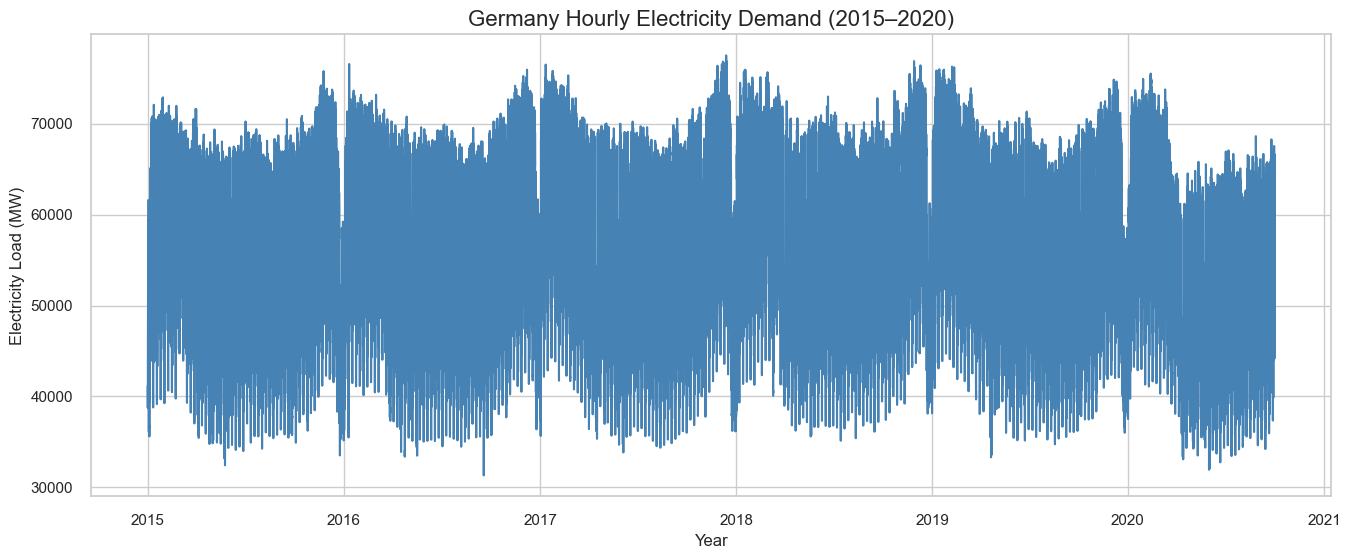

In [9]:
# Hourly Electricity Demand

plt.figure(figsize=(16,6))

plt.plot(hourly_data.index,
         hourly_data['load'],
         color='steelblue')

plt.title("Germany Hourly Electricity Demand (2015–2020)", fontsize=16)

plt.xlabel("Year")
plt.ylabel("Electricity Load (MW)")

plt.grid(True)

plt.show()

## Visualize Daily Electricity Demand

This section plots the daily average electricity demand to observe long-term trends and variations in the data.

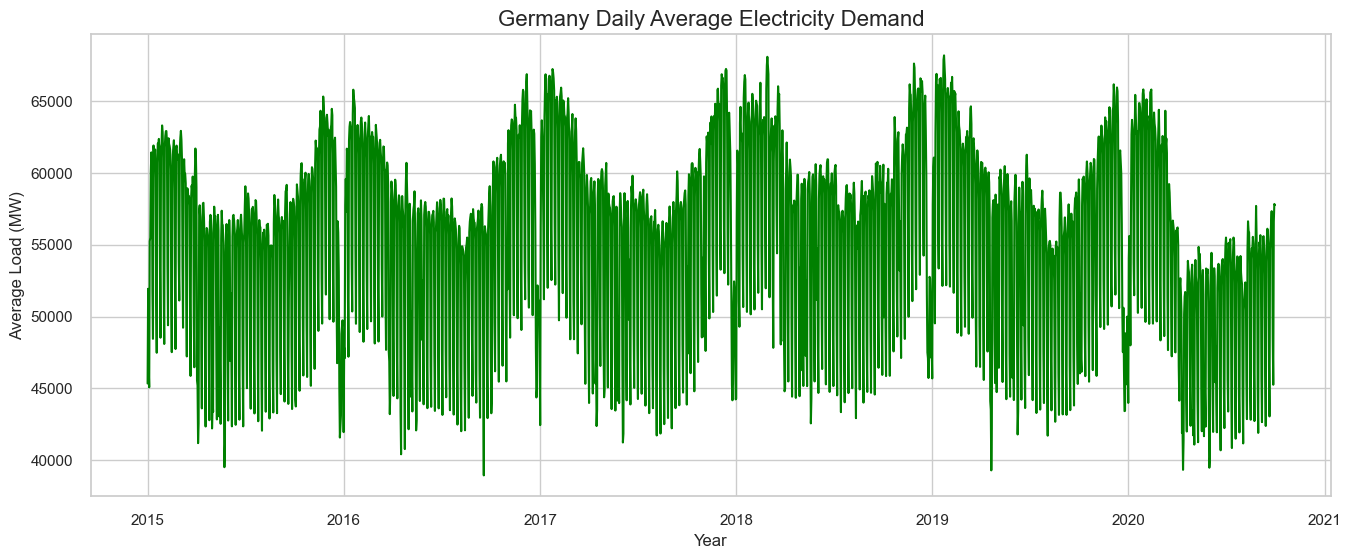

In [10]:
# Cell 10: Daily Electricity Demand

plt.figure(figsize=(16,6))

plt.plot(daily_data.index,
         daily_data['load'],
         color='green')

plt.title("Germany Daily Average Electricity Demand", fontsize=16)

plt.xlabel("Year")
plt.ylabel("Average Load (MW)")

plt.grid(True)

plt.show()

## Visualize Weekly Electricity Demand

This section plots the weekly average electricity demand to highlight overall trends and seasonal patterns in the data.

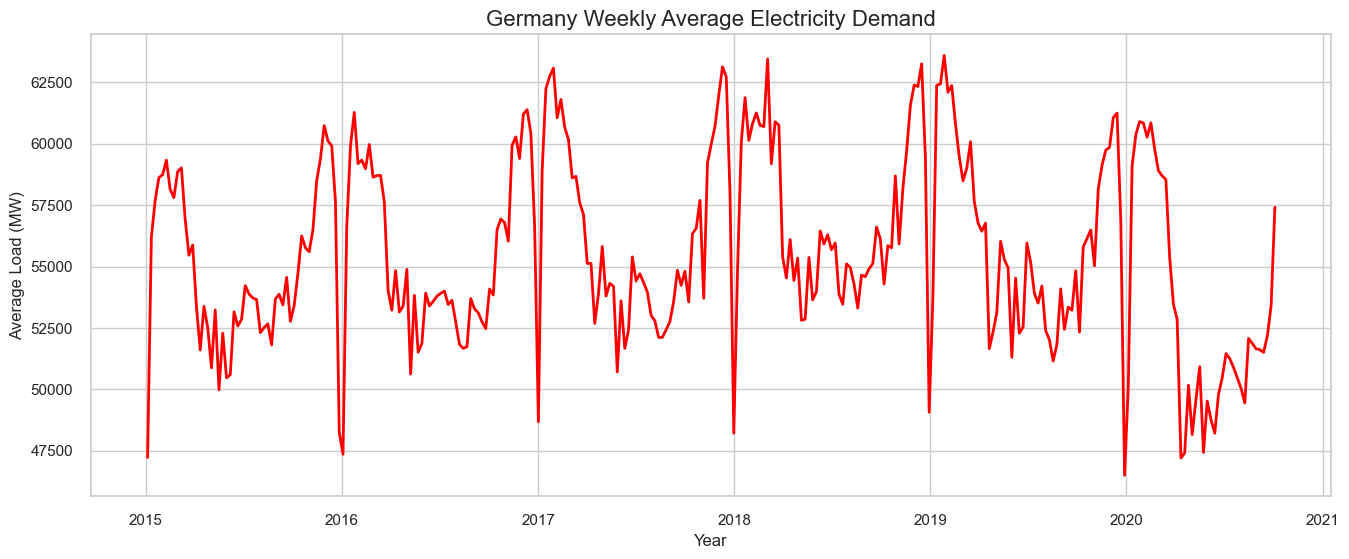

In [11]:
# Weekly Electricity Demand

plt.figure(figsize=(16,6))

plt.plot(weekly_data.index,
         weekly_data['load'],
         color='red',
         linewidth=2)

plt.title("Germany Weekly Average Electricity Demand", fontsize=16)

plt.xlabel("Year")
plt.ylabel("Average Load (MW)")

plt.grid(True)

plt.show()

## Visualize Weekly Electricity Demand

This section plots the weekly average electricity demand to highlight overall trends and seasonal patterns in the data.

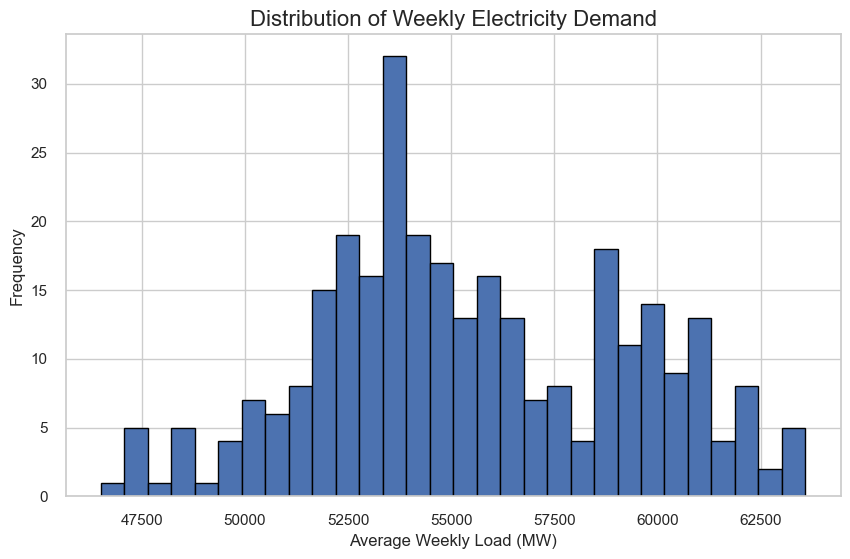

In [12]:
# Distribution of Weekly Electricity Demand

plt.figure(figsize=(10,6))

plt.hist(weekly_data['load'], bins=30, edgecolor='black')

plt.title("Distribution of Weekly Electricity Demand", fontsize=16)
plt.xlabel("Average Weekly Load (MW)")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Box Plot of Weekly Electricity Demand

This section uses a box plot to identify the distribution of weekly electricity demand and detect any potential outliers.

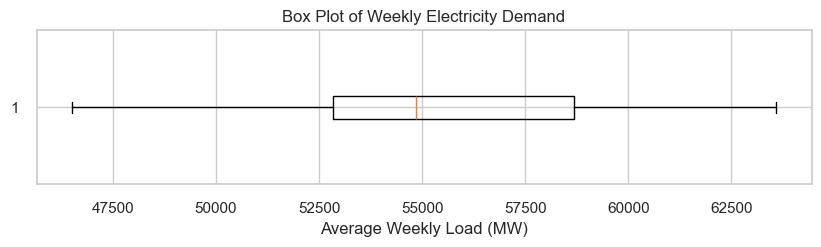

In [13]:
# Cell 13: Box Plot
plt.figure(figsize=(10,2))

plt.boxplot(weekly_data['load'], vert=False)

plt.title("Box Plot of Weekly Electricity Demand")

plt.xlabel("Average Weekly Load (MW)")

plt.show()

## Seasonal Decomposition

This section decomposes the weekly electricity demand into trend, seasonal, and residual components to better understand the underlying patterns in the time series.

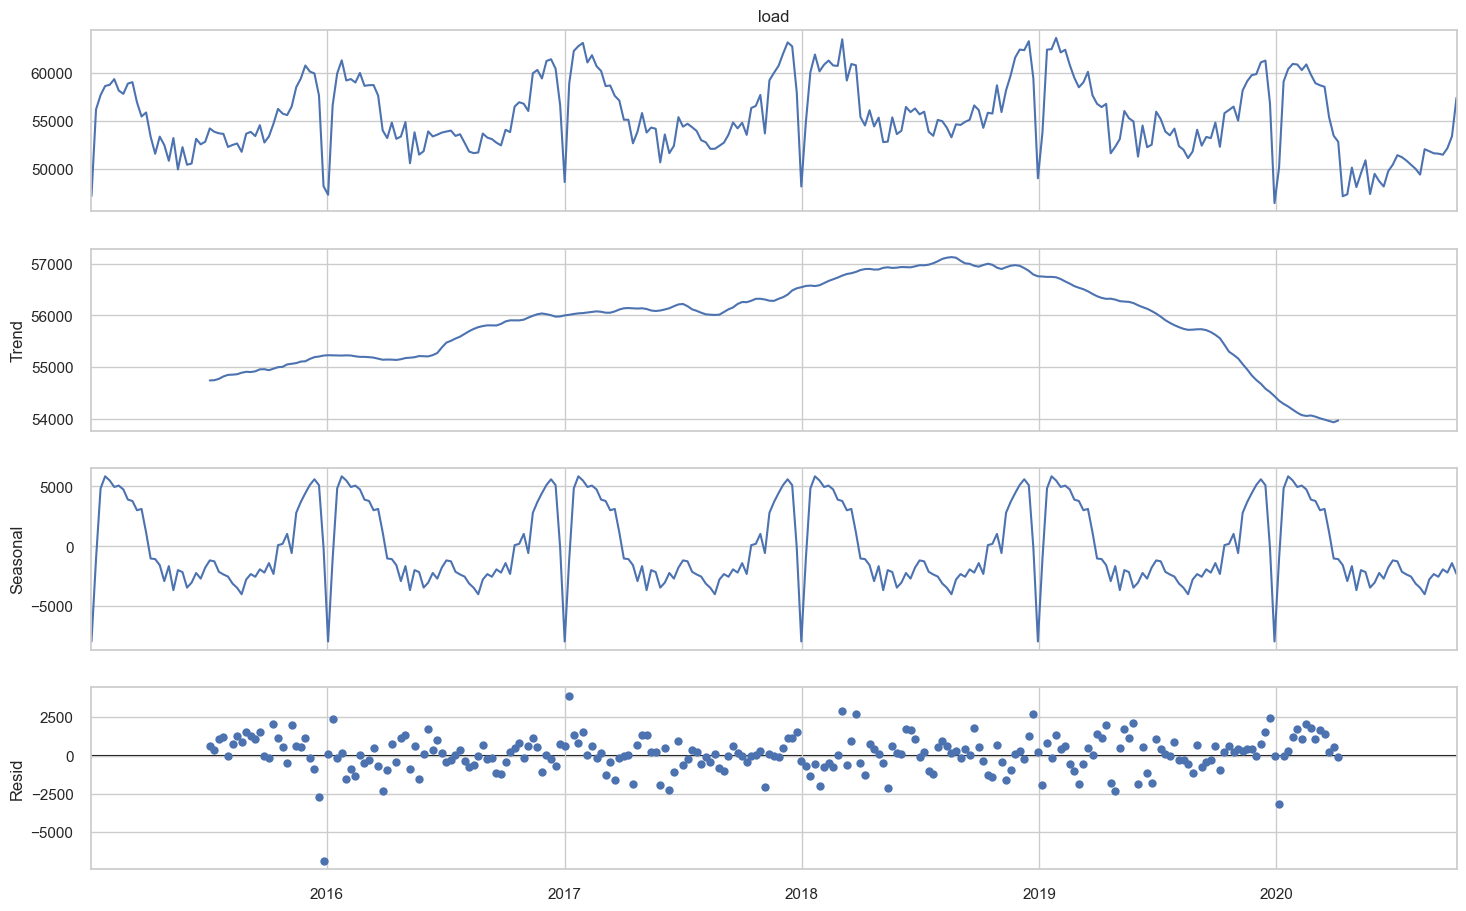

In [14]:
# Cell 14: Seasonal Decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    weekly_data['load'],
    model='additive',
    period=52
)

fig = decomposition.plot()
fig.set_size_inches(16,10)

plt.show()

## Rolling Mean and Rolling Standard Deviation

This section visualizes the rolling mean and rolling standard deviation to assess the trend and stability of the weekly electricity demand over time.

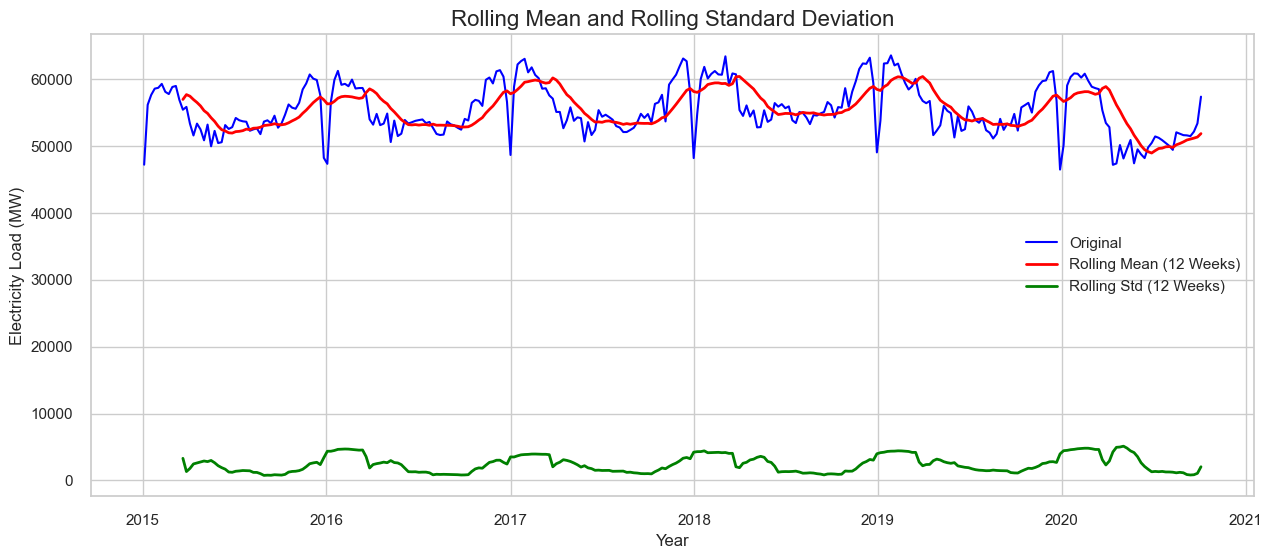

In [15]:
# Cell 15: Rolling Mean and Rolling Standard Deviation

rolling_mean = weekly_data['load'].rolling(window=12).mean()
rolling_std = weekly_data['load'].rolling(window=12).std()

plt.figure(figsize=(15,6))

plt.plot(weekly_data['load'],
         label='Original',
         color='blue')

plt.plot(rolling_mean,
         label='Rolling Mean (12 Weeks)',
         color='red',
         linewidth=2)

plt.plot(rolling_std,
         label='Rolling Std (12 Weeks)',
         color='green',
         linewidth=2)

plt.title("Rolling Mean and Rolling Standard Deviation", fontsize=16)

plt.xlabel("Year")
plt.ylabel("Electricity Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

## Augmented Dickey-Fuller (ADF) Test

This section performs the Augmented Dickey-Fuller (ADF) test to determine whether the weekly electricity demand series is stationary before time series modelling.

In [16]:
# Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

result = adfuller(weekly_data['load'])

print("="*50)
print("Augmented Dickey-Fuller Test")
print("="*50)

print(f"ADF Statistic : {result[0]:.4f}")
print(f"P-value       : {result[1]:.4f}")
print(f"Lags Used     : {result[2]}")
print(f"Observations  : {result[3]}")

print("\nCritical Values")

for key, value in result[4].items():
    print(f"{key}: {value:.4f}")

if result[1] < 0.05:
    print("\nConclusion:")
    print("The series is stationary (Reject H0).")
else:
    print("\nConclusion:")
    print("The series is NOT stationary (Fail to Reject H0).")

Augmented Dickey-Fuller Test
ADF Statistic : -4.0475
P-value       : 0.0012
Lags Used     : 8
Observations  : 292

Critical Values
1%: -3.4529
5%: -2.8715
10%: -2.5721

Conclusion:
The series is stationary (Reject H0).


## Autocorrelation Function (ACF)

This section plots the autocorrelation function to examine the correlation between current and past values of the weekly electricity demand series.

<Figure size 1200x500 with 0 Axes>

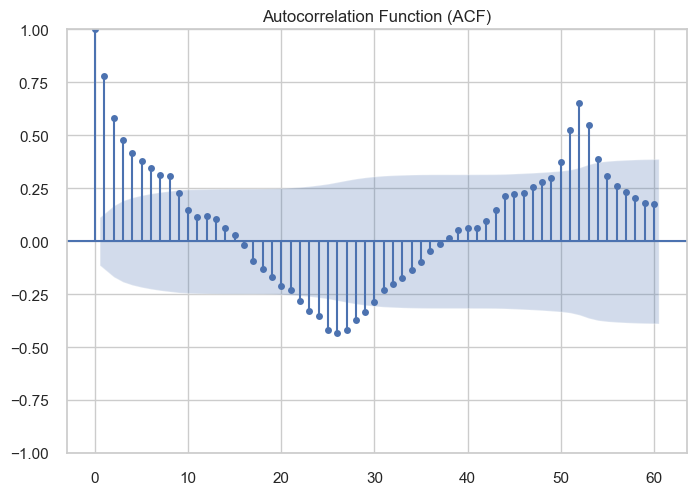

In [17]:
# Autocorrelation Function (ACF)

plt.figure(figsize=(12,5))

plot_acf(weekly_data['load'], lags=60)

plt.title("Autocorrelation Function (ACF)")

plt.show()

## Partial Autocorrelation Function (PACF)

This section plots the partial autocorrelation function to identify the direct relationship between observations at different time lags.

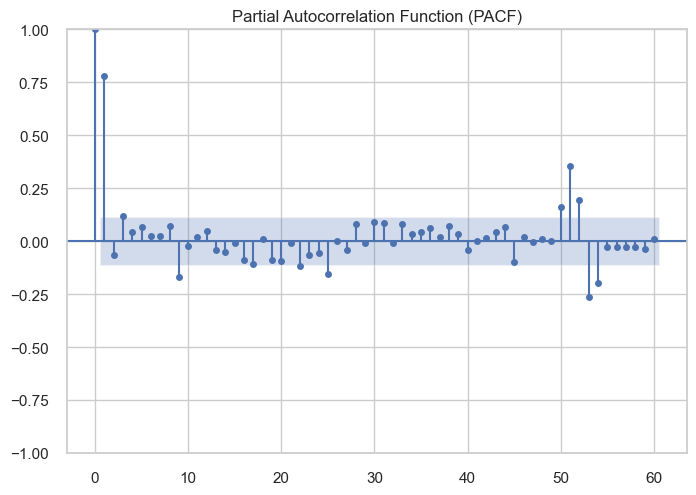

In [18]:
# Partial Autocorrelation Function (PACF)

plot_pacf(
    weekly_data['load'],
    lags=60,
    method='ywm'
)

plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

## Train-Test Split

This section splits the weekly electricity demand data into training and testing sets, reserving the last two years of observations for forecast evaluation.

In [19]:
# Train-Test Split
# Last 104 weeks (2 years) for testing

train = weekly_data.iloc[:-104]
test = weekly_data.iloc[-104:]

print("="*50)
print("Train-Test Split")
print("="*50)

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

print("\nTraining Period")
print(train.index.min())
print(train.index.max())

print("\nTesting Period")
print(test.index.min())
print(test.index.max())

Train-Test Split
Training Shape : (197, 1)
Testing Shape  : (104, 1)

Training Period
2015-01-04 00:00:00+00:00
2018-10-07 00:00:00+00:00

Testing Period
2018-10-14 00:00:00+00:00
2020-10-04 00:00:00+00:00


## Visualize the Train-Test Split

This section visualizes the training and testing datasets, where the last two years of data are reserved for evaluating the forecasting models.

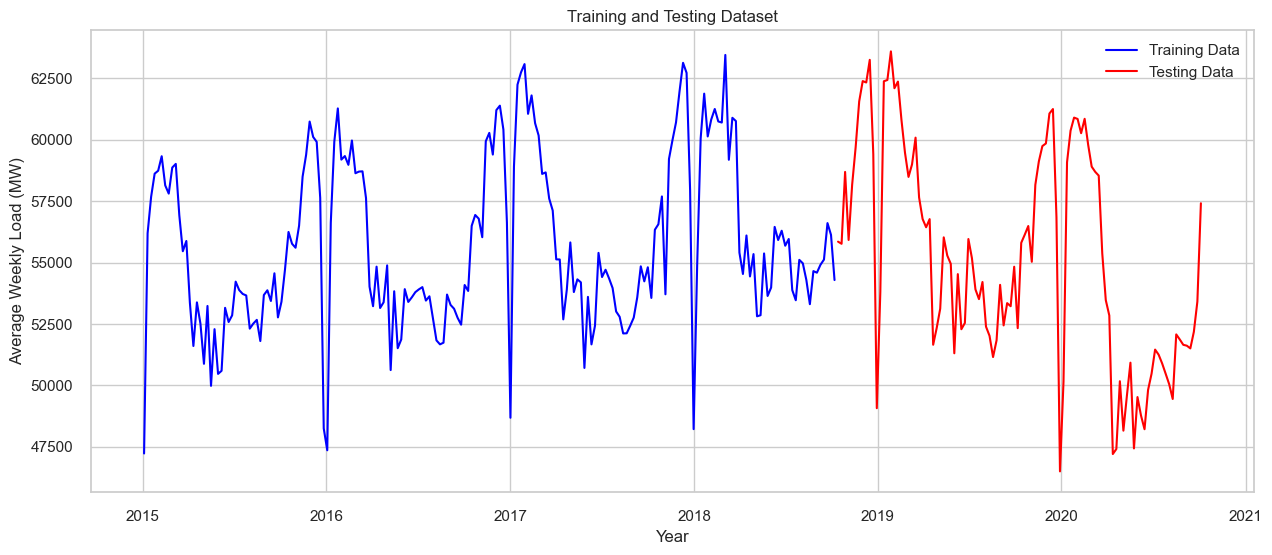

In [20]:
# Cell 20: Train-Test Visualization

plt.figure(figsize=(15,6))

plt.plot(train.index,
         train['load'],
         label='Training Data',
         color='blue')

plt.plot(test.index,
         test['load'],
         label='Testing Data',
         color='red')

plt.title("Training and Testing Dataset")

plt.xlabel("Year")
plt.ylabel("Average Weekly Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

## Mean Forecast

This section generates a simple mean forecast using the average of the training data and compares it with the actual observations.

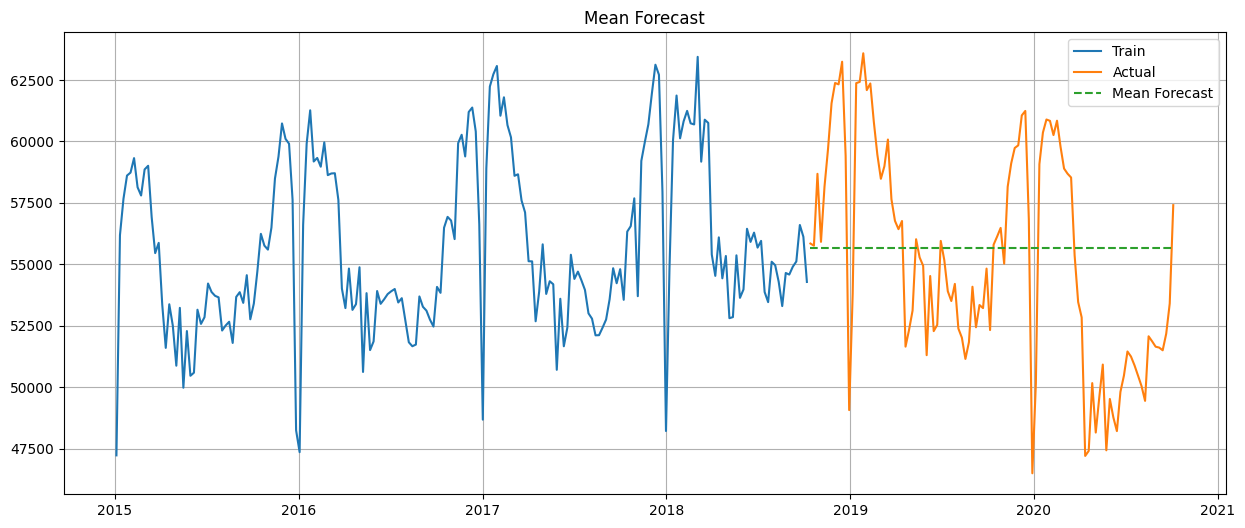

In [49]:
# Mean Forecast
# Mean of training data

mean_value = train['load'].mean()

# Forecast
mean_forecast = np.repeat(mean_value, len(test))

# Store as Series
mean_forecast = pd.Series(
    mean_forecast,
    index=test.index
)

plt.figure(figsize=(15,6))

plt.plot(train.index,
         train['load'],
         label='Train')

plt.plot(test.index,
         test['load'],
         label='Actual')

plt.plot(test.index,
         mean_forecast,
         label='Mean Forecast',
         linestyle='--')

plt.title("Mean Forecast")

plt.legend()

plt.grid(True)

plt.show()

## Naive Forecast

This section generates a naïve forecast by using the last observed value from the training data as the forecast for all future time periods.

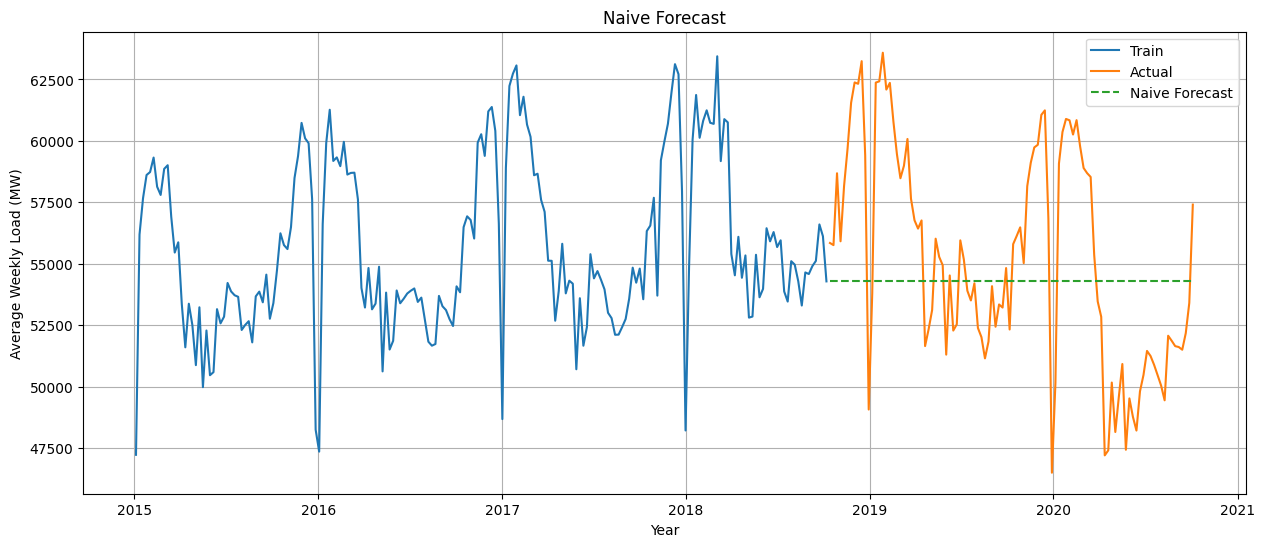

In [58]:
# Naïve Forecast
# Last value from training data

last_value = train['load'].iloc[-1]

# Forecast
naive_forecast = pd.Series(
    np.repeat(last_value, len(test)),
    index=test.index
)

# Plot
plt.figure(figsize=(15,6))

plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(test.index, naive_forecast,
         '--',
         label='Naive Forecast')

plt.title("Naive Forecast")

plt.xlabel("Year")
plt.ylabel("Average Weekly Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

## Seasonal Naive Forecast

This section implements the Seasonal Naïve forecasting model, using the corresponding values from the previous seasonal cycle (52 weeks) as the benchmark forecast.

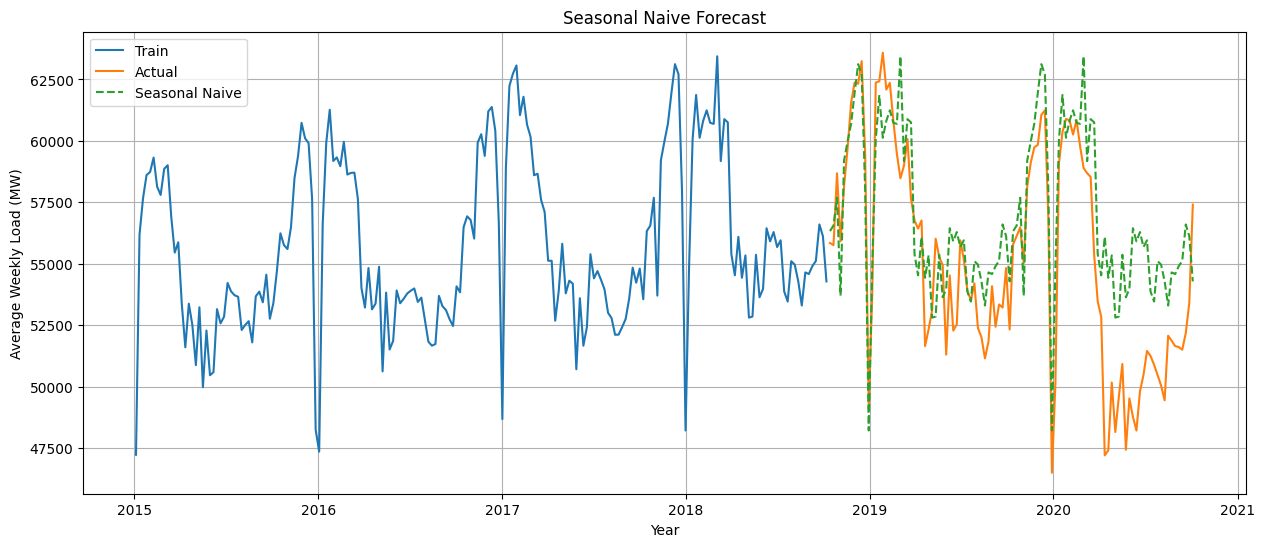

In [59]:
# Seasonal Naïve Forecast

season_length = 52

seasonal_naive_forecast = []

for i in range(len(test)):
    seasonal_naive_forecast.append(
        train['load'].iloc[-season_length + (i % season_length)]
    )

seasonal_naive_forecast = pd.Series(
    seasonal_naive_forecast,
    index=test.index
)

# Plot
plt.figure(figsize=(15,6))

plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(test.index,
         seasonal_naive_forecast,
         '--',
         label='Seasonal Naive')

plt.title("Seasonal Naive Forecast")

plt.xlabel("Year")
plt.ylabel("Average Weekly Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

## Drift Forecast

This section generates a drift forecast by extending the trend observed in the training data and compares the forecast with the actual observations.

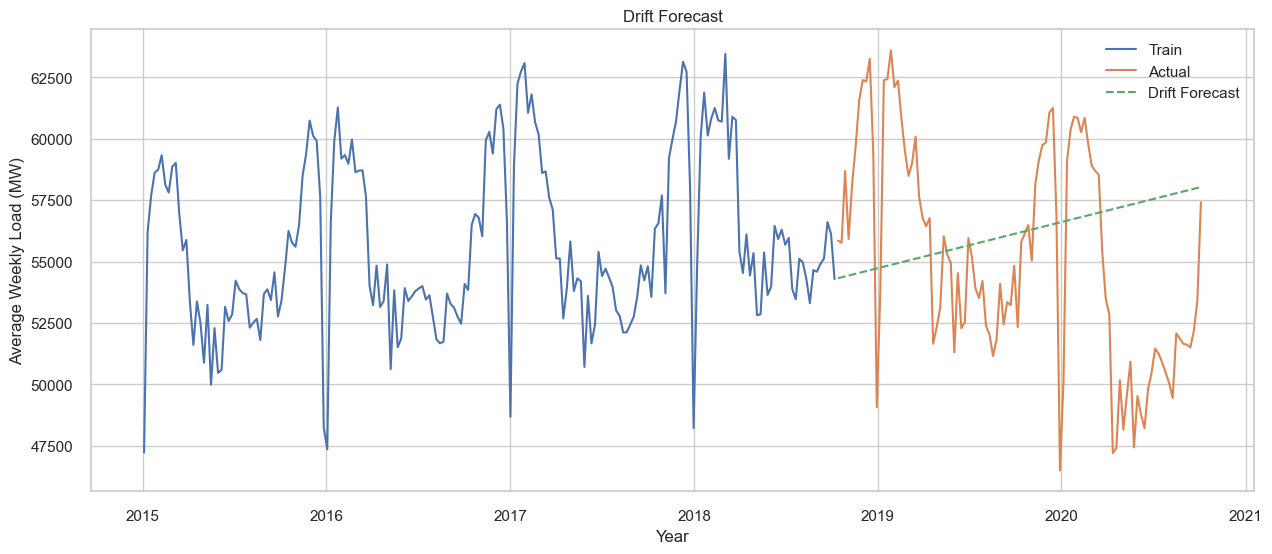

In [24]:
# Drift Forecast

first = train['load'].iloc[0]
last = train['load'].iloc[-1]

drift_forecast = []

for h in range(1, len(test) + 1):
    forecast = last + h * ((last - first) / (len(train) - 1))
    drift_forecast.append(forecast)

drift_forecast = pd.Series(
    drift_forecast,
    index=test.index
)

# Plot
plt.figure(figsize=(15,6))

plt.plot(train.index, train['load'], label='Train')
plt.plot(test.index, test['load'], label='Actual')
plt.plot(test.index,
         drift_forecast,
         '--',
         label='Drift Forecast')

plt.title("Drift Forecast")

plt.xlabel("Year")
plt.ylabel("Average Weekly Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

# Part 2: Benchmark Forecasting Model (Seasonal Naive)

## Evaluate Benchmark Models

This section evaluates the benchmark forecasting models using MAE, RMSE, and MAPE to compare their forecasting performance.

In [25]:
# Evaluate Benchmark Models
# Function to calculate MAPE

def mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

# Dictionary containing all forecasts
forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

results = []

for name, forecast in forecasts.items():

    mae = mean_absolute_error(test['load'], forecast)
    rmse = np.sqrt(mean_squared_error(test['load'], forecast))
    mape_value = mape(test['load'], forecast)

    results.append([name, mae, rmse, mape_value])

# Create comparison table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "MAPE (%)"]
)

results_df = results_df.sort_values("RMSE")

print("="*60)
print("Benchmark Model Comparison")
print("="*60)

display(results_df)

Benchmark Model Comparison


,Model,MAE,RMSE,MAPE (%)
2,Seasonal Naive,2318.520585,3006.760812,4.408920
0,Mean,3788.833122,4397.299694,6.969238
1,Naive,3783.202934,4459.108546,6.790082
3,Drift,4339.890674,5117.957264,8.049685


## Compare Benchmark Forecasts

This section compares the forecasts from all benchmark models against the actual electricity demand to visually assess their forecasting performance.

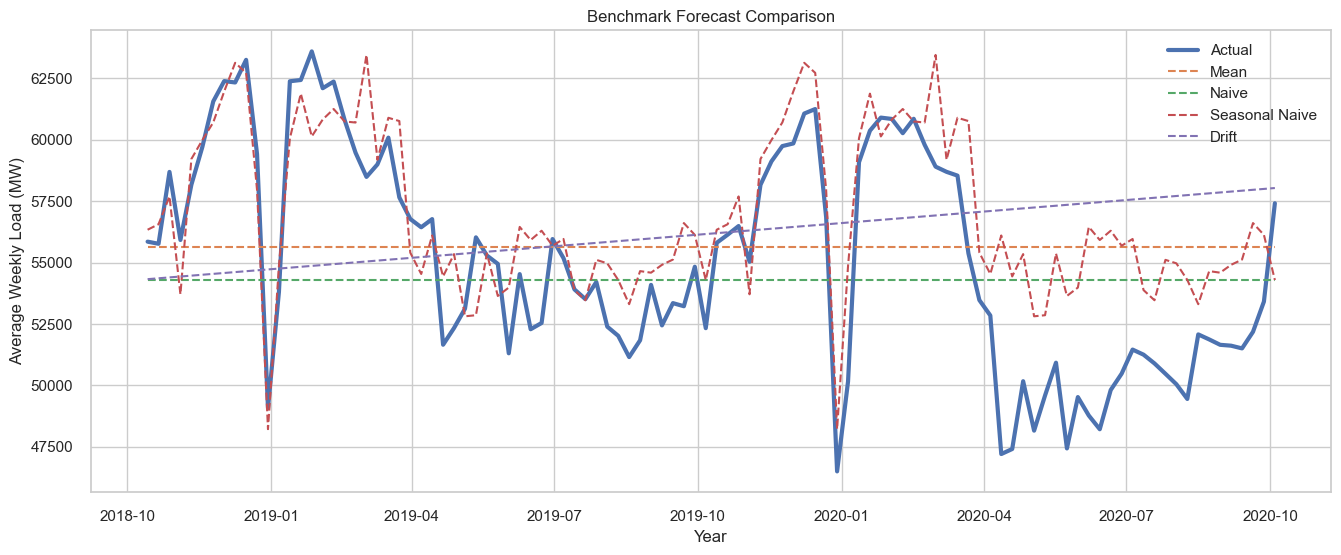

In [26]:
# Compare All Benchmark Forecasts

plt.figure(figsize=(16,6))

plt.plot(test.index,
         test['load'],
         label='Actual',
         linewidth=3)

plt.plot(test.index,
         mean_forecast,
         '--',
         label='Mean')

plt.plot(test.index,
         naive_forecast,
         '--',
         label='Naive')

plt.plot(test.index,
         seasonal_naive_forecast,
         '--',
         label='Seasonal Naive')

plt.plot(test.index,
         drift_forecast,
         '--',
         label='Drift')

plt.title("Benchmark Forecast Comparison")

plt.xlabel("Year")
plt.ylabel("Average Weekly Load (MW)")

plt.legend()

plt.grid(True)

plt.show()

## Identify the Best Benchmark Model

This section identifies the best-performing benchmark model based on the evaluation metrics and summarizes its forecasting performance.

In [27]:
# Best Benchmark Model

best_model = results_df.iloc[0]

print("="*60)
print("Best Benchmark Model")
print("="*60)

print(f"Model : {best_model['Model']}")
print(f"RMSE  : {best_model['RMSE']:.2f}")
print(f"MAE   : {best_model['MAE']:.2f}")
print(f"MAPE  : {best_model['MAPE (%)']:.2f}%")

Best Benchmark Model
Model : Seasonal Naive
RMSE  : 3006.76
MAE   : 2318.52
MAPE  : 4.41%


# Part 3: SARIMA Model
## Import Libraries for SARIMA

This section imports the libraries required to build, train, and evaluate the SARIMA forecasting model.

In [28]:
# Import Libraries for SARIMA
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import itertools

## Perform SARIMA Hyperparameter Tuning

This section performs a grid search to identify the optimal SARIMA model by evaluating different parameter combinations using the Akaike Information Criterion (AIC).


In [29]:
# SARIMA Grid Search

# Parameter ranges
p = d = q = range(0, 3)

# Seasonal parameters
P = D = Q = range(0, 2)

# Generate combinations
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q))

best_aic = float("inf")
best_order = None
best_seasonal = None

print("Searching for the best SARIMA model...\n")

for order in pdq:
    for seasonal in seasonal_pdq:

        seasonal_order = (
            seasonal[0],
            seasonal[1],
            seasonal[2],
            52
        )

        try:

            model = SARIMAX(
                train['load'],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            if result.aic < best_aic:

                best_aic = result.aic
                best_order = order
                best_seasonal = seasonal_order

        except:
            continue

print("="*60)
print("Best SARIMA Model")
print("="*60)

print("Order:", best_order)
print("Seasonal Order:", best_seasonal)
print("AIC:", round(best_aic,2))

Searching for the best SARIMA model...

Best SARIMA Model
Order: (2, 2, 2)
Seasonal Order: (0, 0, 1, 52)
AIC: 352.49


## Train the SARIMA Model

This section trains the selected SARIMA model using the optimal parameters and displays the model summary for further analysis.

In [35]:
# Fit Stable SARIMA Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("="*60)
print("Fitting Stable SARIMA Model...")
print("="*60)

# Stable SARIMA model
sarima_model = SARIMAX(
    train['load'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 52),
    enforce_stationarity=True,
    enforce_invertibility=True
)

# Train the model
sarima_result = sarima_model.fit()

print("="*60)
print("SARIMA Model Successfully Trained")
print("="*60)

# Display model summary
print(sarima_result.summary())

Fitting Stable SARIMA Model...
SARIMA Model Successfully Trained
                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                  197
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -1756.052
Date:                            Sat, 11 Jul 2026   AIC                           3522.104
Time:                                    05:20:24   BIC                           3538.520
Sample:                                01-04-2015   HQIC                          3528.749
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9977      0.006    159.839      

## Generate SARIMA Forecast

This section generates forecasts for the testing period using the trained SARIMA model and displays the first few predicted values.

In [36]:
# Generate Forecast Using SARIMA

# Forecast for the test period
sarima_forecast = sarima_result.forecast(steps=len(test))

# Convert to Series with the same index as the test data
sarima_forecast = pd.Series(
    sarima_forecast,
    index=test.index
)

print("First 5 Forecast Values:")
display(sarima_forecast.head())

First 5 Forecast Values:


timestamp
2018-10-14 00:00:00+00:00    57462.312876
2018-10-21 00:00:00+00:00    57512.596630
2018-10-28 00:00:00+00:00    57766.928177
2018-11-04 00:00:00+00:00    56514.260514
2018-11-11 00:00:00+00:00    59982.835523
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [37]:
# Evaluate SARIMA Model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test['load'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['load'], sarima_forecast))
sarima_mape = np.mean(np.abs((test['load'] - sarima_forecast) / test['load'])) * 100

print("="*60)
print("SARIMA Model Performance")
print("="*60)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

SARIMA Model Performance
MAE  : 2263.75
RMSE : 2883.07
MAPE : 4.32%


## Evaluate the SARIMA Model

This section evaluates the forecasting performance of the SARIMA model using MAE, RMSE, and MAPE.

In [37]:
# Evaluate SARIMA Model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
sarima_mae = mean_absolute_error(test['load'], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test['load'], sarima_forecast))
sarima_mape = np.mean(np.abs((test['load'] - sarima_forecast) / test['load'])) * 100

print("="*60)
print("SARIMA Model Performance")
print("="*60)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

SARIMA Model Performance
MAE  : 2263.75
RMSE : 2883.07
MAPE : 4.32%


## Visualize the SARIMA Forecast

This section compares the SARIMA forecast with the actual electricity demand over the testing period to assess forecasting accuracy.

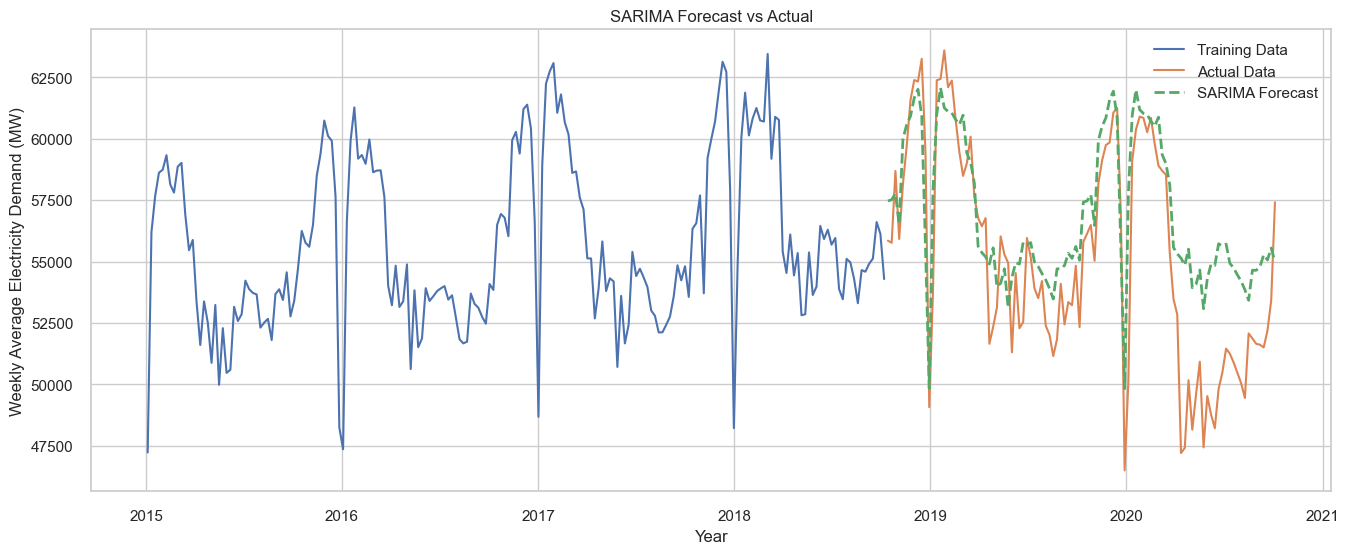

In [38]:
# SARIMA Forecast Plot

plt.figure(figsize=(16,6))

plt.plot(train.index, train['load'], label='Training Data')
plt.plot(test.index, test['load'], label='Actual Data')
plt.plot(test.index, sarima_forecast,
         '--',
         linewidth=2,
         label='SARIMA Forecast')

plt.title("SARIMA Forecast vs Actual")

plt.xlabel("Year")
plt.ylabel("Weekly Average Electricity Demand (MW)")

plt.legend()
plt.grid(True)

plt.show()

## Compare Benchmark and SARIMA Models

This section compares the forecasting performance of the benchmark models and the SARIMA model using the selected evaluation metrics.

In [39]:
# Update Comparison Table

sarima_result_df = pd.DataFrame({
    "Model": ["SARIMA"],
    "MAE": [sarima_mae],
    "RMSE": [sarima_rmse],
    "MAPE (%)": [sarima_mape]
})

results_df = pd.concat([results_df, sarima_result_df], ignore_index=True)

# Sort by RMSE (lowest is best)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("="*60)
print("Benchmark Models + SARIMA Comparison")
print("="*60)

display(results_df)

Benchmark Models + SARIMA Comparison


,Model,MAE,RMSE,MAPE (%)
0,SARIMA,2.263754e+03,2.883071e+03,4.323478e+00
1,Seasonal Naive,2.318521e+03,3.006761e+03,4.408920e+00
2,Mean,3.788833e+03,4.397300e+03,6.969238e+00
3,Naive,3.783203e+03,4.459109e+03,6.790082e+00
4,Drift,4.339891e+03,5.117957e+03,8.049685e+00
5,SARIMA,7.963339e+116,5.496165e+117,1.431505e+114


## Analyse SARIMA Residuals

This section analyses the residuals of the SARIMA model to assess model assumptions and evaluate the overall quality of the forecasts.

Residual Summary Statistics
count      197.000000
mean       384.980526
std       3854.412067
min      -9964.008981
25%       -882.581753
50%        150.558196
75%       1215.971917
max      47233.739583
dtype: float64


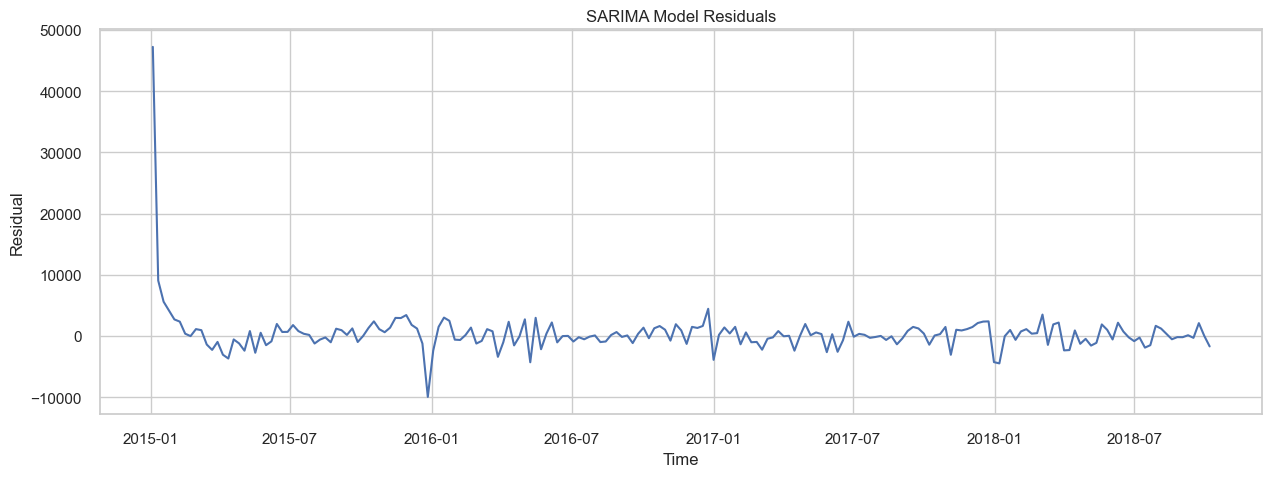

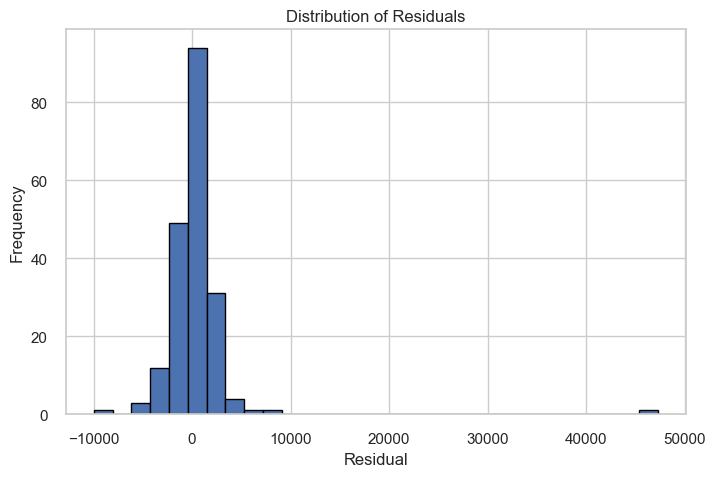

In [40]:
# Residual Analysis

# Extract residuals
residuals = sarima_result.resid

print("="*60)
print("Residual Summary Statistics")
print("="*60)

print(residuals.describe())

# Plot residuals
plt.figure(figsize=(15,5))

plt.plot(residuals)

plt.title("SARIMA Model Residuals")

plt.xlabel("Time")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

# Histogram
plt.figure(figsize=(8,5))

plt.hist(residuals,
         bins=30,
         edgecolor='black')

plt.title("Distribution of Residuals")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

## Examine Residual Autocorrelation

This section plots the autocorrelation of the SARIMA residuals to check for any remaining temporal patterns in the model errors.

<Figure size 1200x500 with 0 Axes>

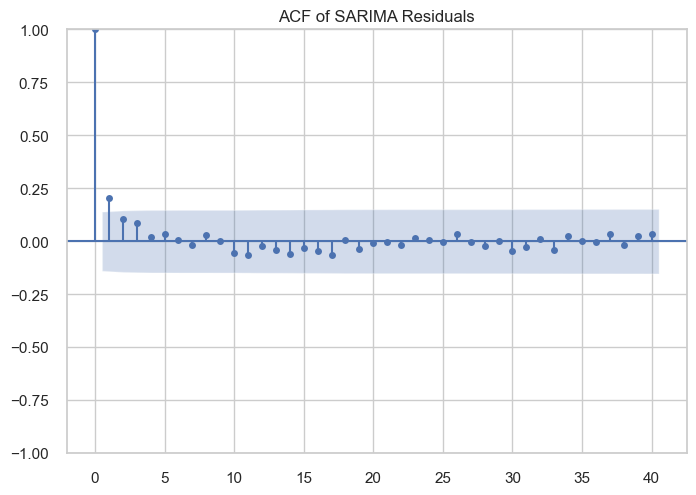

In [41]:
# Residual ACF

from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    residuals,
    lags=40
)

plt.title("ACF of SARIMA Residuals")

plt.show()

## Forecast with Confidence Intervals

This section visualises the SARIMA forecasts along with the 95% confidence intervals to illustrate the uncertainty associated with the predictions.

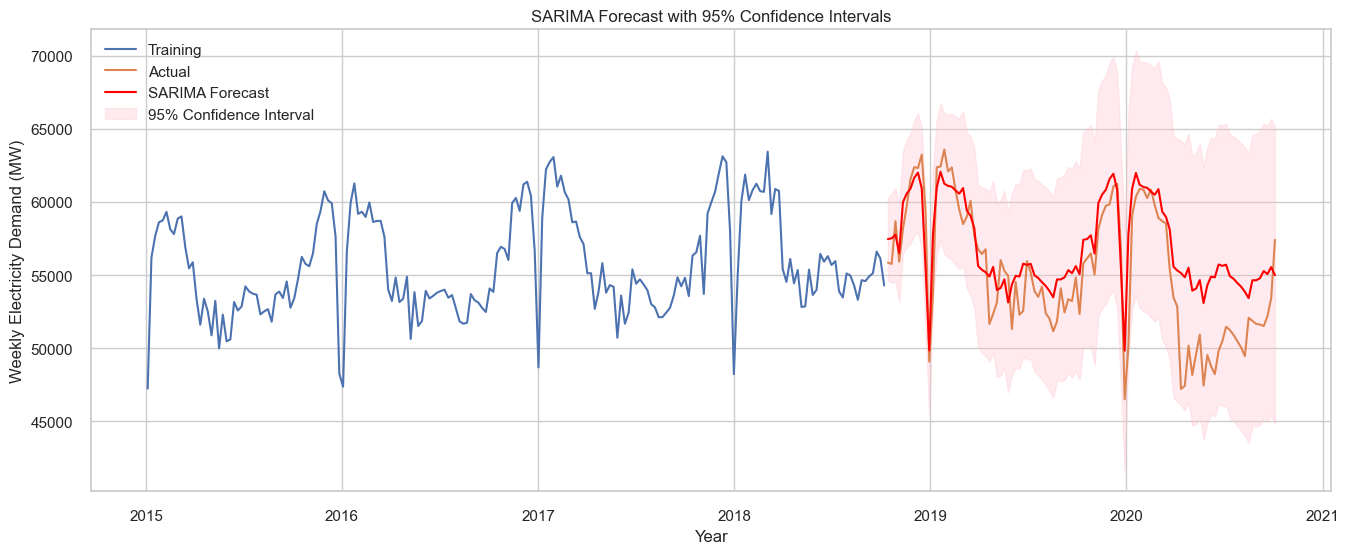

In [42]:
# Forecast with Confidence Intervals
# Forecast object

forecast = sarima_result.get_forecast(
    steps=len(test)
)

forecast_mean = forecast.predicted_mean

confidence_intervals = forecast.conf_int()

# Plot
plt.figure(figsize=(16,6))

plt.plot(
    train.index,
    train['load'],
    label='Training'
)

plt.plot(
    test.index,
    test['load'],
    label='Actual'
)

plt.plot(
    test.index,
    forecast_mean,
    label='SARIMA Forecast',
    color='red'
)

plt.fill_between(
    test.index,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("SARIMA Forecast with 95% Confidence Intervals")

plt.xlabel("Year")

plt.ylabel("Weekly Electricity Demand (MW)")

plt.legend()

plt.grid(True)

plt.show()

# Part 4: SARIMAX Model
## Retrieve Weather Data

This section retrieves historical temperature data from the Open-Meteo API for use as an external variable in the SARIMAX model.

In [1]:
import requests

url = "https://archive-api.open-meteo.com/v1/archive?latitude=52.52&longitude=13.41&start_date=2015-01-01&end_date=2020-09-30&daily=temperature_2m_mean&timezone=Europe/Berlin"

response = requests.get(url)

print("Status Code:", response.status_code)
print(response.text[:500])

Status Code: 200
{"latitude":52.54833,"longitude":13.407822,"generationtime_ms":429.37493324279785,"utc_offset_seconds":7200,"timezone":"Europe/Berlin","timezone_abbreviation":"GMT+2","elevation":38.0,"daily_units":{"time":"iso8601","temperature_2m_mean":"°C"},"daily":{"time":["2015-01-01","2015-01-02","2015-01-03","2015-01-04","2015-01-05","2015-01-06","2015-01-07","2015-01-08","2015-01-09","2015-01-10","2015-01-11","2015-01-12","2015-01-13","2015-01-14","2015-01-15","2015-01-16","2015-01-17","2015-01-18","2015


## Retrieve Berlin Temperature Data

This section retrieves historical daily temperature data for Berlin from the Open-Meteo API to use as an external variable in the SARIMAX model.

In [2]:
# Retrieve Berlin Temperature Data

import requests
import pandas as pd

# Open-Meteo API URL
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    "?latitude=52.52"
    "&longitude=13.41"
    "&start_date=2015-01-01"
    "&end_date=2020-09-30"
    "&daily=temperature_2m_mean"
    "&timezone=Europe/Berlin"
)

# Retrieve data
response = requests.get(url)

print("Status Code:", response.status_code)

# Convert JSON response to Python dictionary
weather = response.json()

Status Code: 200


## Create the Temperature Dataset

This section creates a temperature dataset from the retrieved weather data and performs a basic inspection of its structure and data quality.

In [3]:
#Create Temperature Dataset

temperature = pd.DataFrame({
    "date": weather["daily"]["time"],
    "temperature": weather["daily"]["temperature_2m_mean"]
})

# Convert date column to datetime
temperature["date"] = pd.to_datetime(temperature["date"])

print("="*60)
print("Temperature Dataset")
print("="*60)

print("Shape:", temperature.shape)

print("\nMissing Values:")
print(temperature.isnull().sum())

print("\nFirst 5 Rows:")
print(temperature.head())

Temperature Dataset
Shape: (2100, 2)

Missing Values:
date           0
temperature    0
dtype: int64

First 5 Rows:
        date  temperature
0 2015-01-01          2.8
1 2015-01-02          4.6
2 2015-01-03          3.9
3 2015-01-04          3.0
4 2015-01-05          2.7


## Visualise the Temperature Data

This section visualises the daily mean temperature in Berlin from 2015 to 2020 to examine its overall trend and seasonal variation.

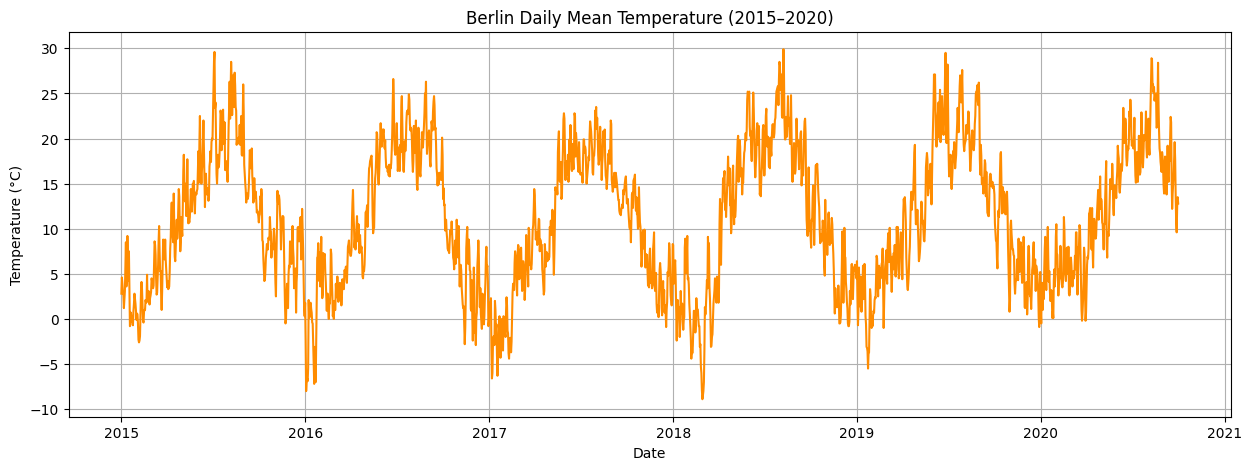

In [4]:
# Berlin Temperature Time Series

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    temperature["date"],
    temperature["temperature"],
    color="darkorange"
)

plt.title("Berlin Daily Mean Temperature (2015–2020)")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

## Convert Temperature to Weekly Data

This section converts the daily temperature data into weekly averages to align it with the weekly electricity demand dataset.

In [5]:
# Convert Daily Temperature to Weekly Average
# Set date as index
temperature = temperature.set_index("date")

# Convert daily temperature to weekly average
temperature_weekly = temperature.resample("W").mean()

print("="*60)
print("Weekly Temperature Dataset")
print("="*60)

print("Shape:", temperature_weekly.shape)

print("\nFirst 5 Rows:")
print(temperature_weekly.head())

Weekly Temperature Dataset
Shape: (301, 1)

First 5 Rows:
            temperature
date                   
2015-01-04     3.575000
2015-01-11     3.885714
2015-01-18     4.900000
2015-01-25     0.028571
2015-02-01     1.414286


## Visualise Weekly Temperature Data

This section visualises the weekly average temperature in Berlin to identify seasonal patterns and trends before incorporating it into the SARIMAX model.

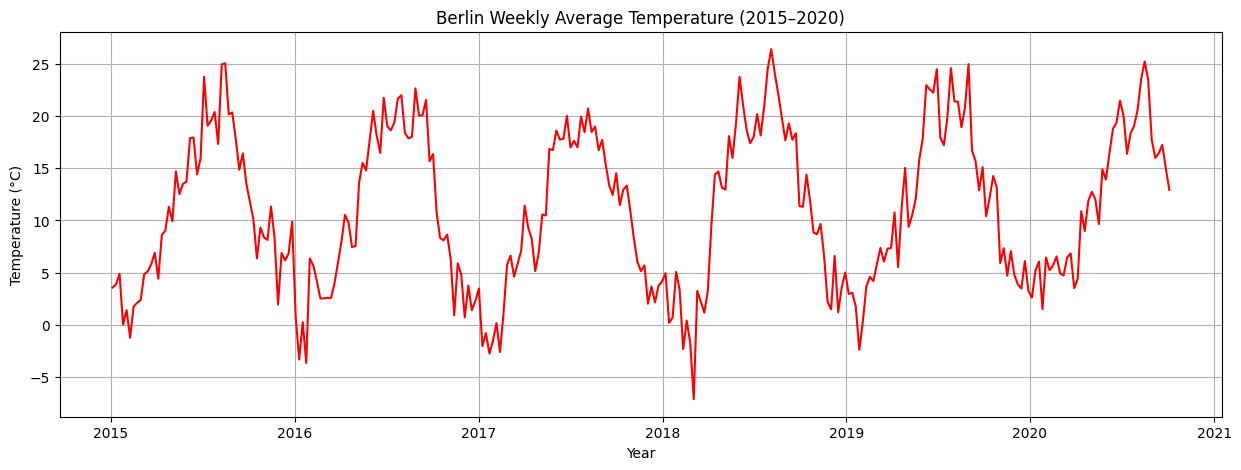

In [6]:
# Weekly Average Temperature

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    temperature_weekly.index,
    temperature_weekly["temperature"],
    color="red"
)

plt.title("Berlin Weekly Average Temperature (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

## Merge Load and Temperature Data

This section merges the weekly electricity demand and weekly temperature datasets to create the final dataset for SARIMAX modelling.

In [54]:
# Merge Weekly Load and Temperature

weekly_data = weekly_data.copy()

# Remove timezone so both indexes match
weekly_data.index = weekly_data.index.tz_localize(None)

temperature_weekly.index = temperature_weekly.index.tz_localize(None)

# Merge
sarimax_data = weekly_data.join(temperature_weekly, how="inner")

print("="*60)
print("Merged Dataset")
print("="*60)

print("Shape:", sarimax_data.shape)

print("\nMissing Values:")
print(sarimax_data.isnull().sum())

print("\nFirst 5 Rows:")
print(sarimax_data.head())

Merged Dataset
Shape: (301, 2)

Missing Values:
load           0
temperature    0
dtype: int64

First 5 Rows:
                    load  temperature
timestamp                            
2015-01-04  47233.739583     3.575000
2015-01-11  56191.101190     3.885714
2015-01-18  57672.678571     4.900000
2015-01-25  58613.303571     0.028571
2015-02-01  58734.029762     1.414286


## Prepare Training and Testing Data

This section splits the merged dataset into training and testing sets and separates the target and temperature variables for SARIMAX modelling.

In [16]:
# Cell 44: Train-Test Split for SARIMAX
# Last 104 weeks (2 years) for testing
train = sarimax_data.iloc[:-104]
test = sarimax_data.iloc[-104:]

# Target variable
y_train = train["load"]
y_test = test["load"]

# Exogenous variable
X_train = train[["temperature"]]
X_test = test[["temperature"]]

print("=" * 60)
print("SARIMAX Train-Test Split")
print("=" * 60)

print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

print("\nTraining Period")
print(train.index.min())
print(train.index.max())

print("\nTesting Period")
print(test.index.min())
print(test.index.max())

SARIMAX Train-Test Split
Training Shape : (197, 2)
Testing Shape  : (104, 2)

Training Period
2015-01-04 00:00:00
2018-10-07 00:00:00

Testing Period
2018-10-14 00:00:00
2020-10-04 00:00:00


## Explore the Relationship Between Temperature and Electricity Demand

This section visualises the relationship between weekly average temperature and electricity demand to assess the potential influence of temperature on electricity consumption.

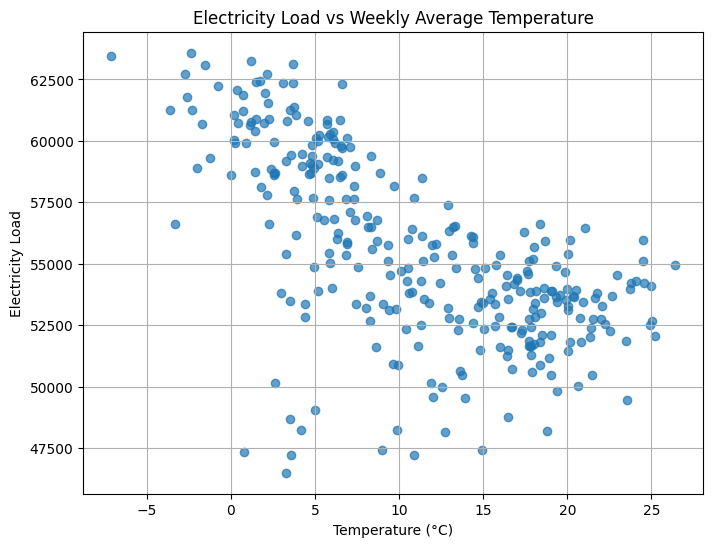

In [17]:
# Relationship Between Temperature and Load

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    sarimax_data["temperature"],
    sarimax_data["load"],
    alpha=0.7
)

plt.title("Electricity Load vs Weekly Average Temperature")

plt.xlabel("Temperature (°C)")
plt.ylabel("Electricity Load")

plt.grid(True)

plt.show()

## Train the SARIMAX Model

This section trains the SARIMAX model using electricity demand and temperature data, and presents the model summary for evaluation.

In [18]:
#Train SARIMAX Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("="*60)
print("Training SARIMAX Model...")
print("="*60)

sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_results = sarimax_model.fit(disp=False)

print("="*60)
print("SARIMAX Model Successfully Trained")
print("="*60)

print(sarimax_results.summary())

Training SARIMAX Model...


C:\Users\maddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\maddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\maddi\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX Model Successfully Trained
                                     SARIMAX Results                                      
Dep. Variable:                               load   No. Observations:                  197
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -7956.521
Date:                            Wed, 15 Jul 2026   AIC                          15925.041
Time:                                    15:20:23   BIC                          15942.818
Sample:                                01-04-2015   HQIC                         15932.265
                                     - 10-07-2018                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  3355.3910      2.800   1198.532      0.000    3349.904    3360.8

## Generate SARIMAX Forecast

This section generates forecasts for the testing period using the trained SARIMAX model and produces the predicted values with confidence intervals.

In [19]:
# Forecast with SARIMAX

sarimax_forecast = sarimax_results.get_forecast(
    steps=len(y_test),
    exog=X_test
)

forecast_mean = sarimax_forecast.predicted_mean
forecast_ci = sarimax_forecast.conf_int()

print("="*60)
print("First 5 Forecast Values")
print("="*60)

print(forecast_mean.head())

First 5 Forecast Values
2018-10-14   -1.921422e+13
2018-10-21   -1.780856e+13
2018-10-28   -1.650574e+13
2018-11-04   -1.529822e+13
2018-11-11   -1.417905e+13
Freq: W-SUN, Name: predicted_mean, dtype: float64


## Evaluate the SARIMAX Model

This section evaluates the forecasting performance of the SARIMAX model using MAE, RMSE, and MAPE.

In [20]:
# Evaluate SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, forecast_mean)
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
mape = mean_absolute_percentage_error(y_test, forecast_mean) * 100

print("="*60)
print("SARIMAX Performance")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

SARIMAX Performance
MAE  : 7529595038064.66
RMSE : 17648239793900.39
MAPE : 13566087635.55%


## Tune the SARIMAX Model

This section performs a grid search to identify the optimal SARIMAX model by evaluating different parameter combinations using the Akaike Information Criterion (AIC).

In [21]:
#  Find Best SARIMAX Model using AIC

import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

# Smaller parameter search (fast and stable)
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)

pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(P, 0, Q, 52) for P in range(0,2) for Q in range(0,2)]

best_aic = float("inf")
best_order = None
best_seasonal = None
best_model = None

print("Searching for the best SARIMAX model...\n")

for order in pdq:
    for seasonal_order in seasonal_pdq:

        try:

            model = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            results = model.fit(disp=False)

            if results.aic < best_aic:

                best_aic = results.aic
                best_order = order
                best_seasonal = seasonal_order
                best_model = results

        except:
            continue

print("="*60)
print("Best SARIMAX Model")
print("="*60)

print("Order:", best_order)
print("Seasonal Order:", best_seasonal)
print("AIC:", round(best_aic,2))

Searching for the best SARIMAX model...

Best SARIMAX Model
Order: (2, 1, 1)
Seasonal Order: (1, 0, 0, 52)
AIC: 2489.75


## Train the Final SARIMAX Model

This section trains the final SARIMAX model using the optimal parameters identified during tuning and presents the model summary for interpretation.

In [22]:

# Train Final SARIMAX Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("="*60)
print("Training Final SARIMAX Model")
print("="*60)

final_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=(2,1,1),
    seasonal_order=(1,0,0,52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_sarimax.fit(disp=False)

print("="*60)
print("Final SARIMAX Model Summary")
print("="*60)

print(final_results.summary())

Training Final SARIMAX Model
Final SARIMAX Model Summary
                                      SARIMAX Results                                      
Dep. Variable:                                load   No. Observations:                  197
Model:             SARIMAX(2, 1, 1)x(1, 0, [], 52)   Log Likelihood               -1238.873
Date:                             Wed, 15 Jul 2026   AIC                           2489.746
Time:                                     15:33:29   BIC                           2507.481
Sample:                                 01-04-2015   HQIC                          2496.952
                                      - 10-07-2018                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperature  -169.0974     35.170     -4.808   

## Generate Final SARIMAX Forecast

This section generates forecasts for the testing period using the final SARIMAX model and presents the predicted values for evaluation.

In [23]:
# Forecast using Final SARIMAX


forecast = final_results.get_forecast(
    steps=len(y_test),
    exog=X_test
)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

print("="*60)
print("First Five Forecast Values")
print("="*60)

print(forecast_mean.head())

First Five Forecast Values
2018-10-14    56944.933457
2018-10-21    57658.556570
2018-10-28    58807.965046
2018-11-04    55604.721173
2018-11-11    59217.293128
Freq: W-SUN, Name: predicted_mean, dtype: float64


## Evaluate the Final SARIMAX Model

This section evaluates the forecasting performance of the final SARIMAX model using MAE, RMSE, and MAPE.

In [24]:
# Evaluate Final SARIMAX Model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, forecast_mean)
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
mape = mean_absolute_percentage_error(y_test, forecast_mean) * 100

print("="*60)
print("Final SARIMAX Performance")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

Final SARIMAX Performance
MAE  : 3265.97
RMSE : 4309.87
MAPE : 6.31%


## Visualise the Final SARIMAX Forecast

This section compares the final SARIMAX forecasts with the actual electricity demand and displays the 95% confidence intervals around the predictions.

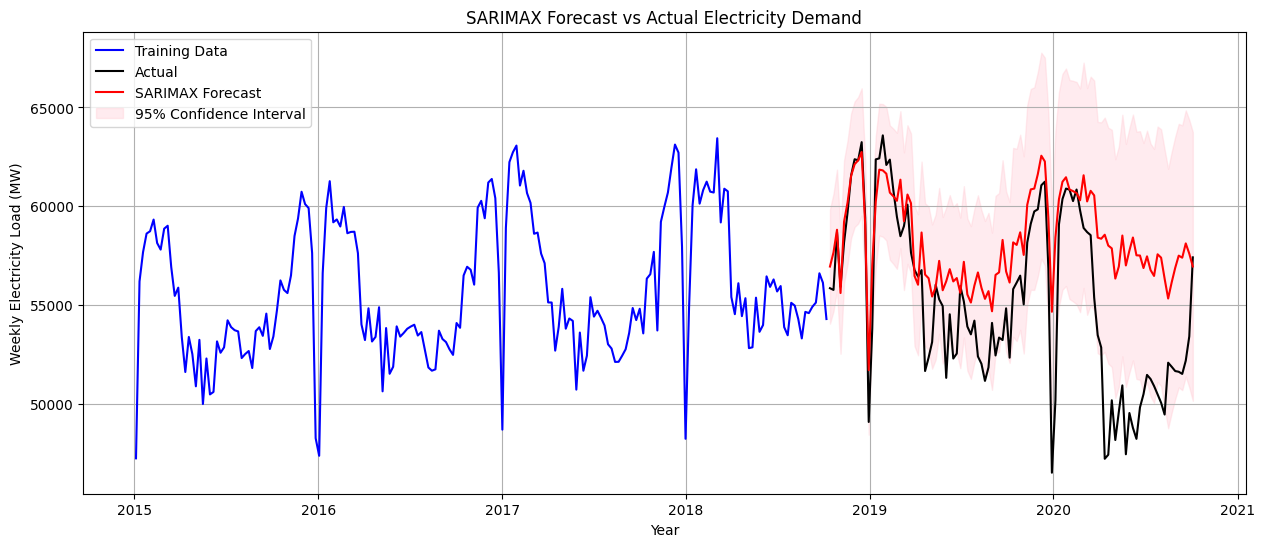

In [25]:
#  Forecast vs Actual with Confidence Intervals

plt.figure(figsize=(15,6))

# Training data
plt.plot(
    y_train.index,
    y_train,
    label="Training Data",
    color="blue"
)

# Actual test data
plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    color="black"
)

# Forecast
plt.plot(
    forecast_mean.index,
    forecast_mean,
    label="SARIMAX Forecast",
    color="red"
)

# Confidence interval
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMAX Forecast vs Actual Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Weekly Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

## Perform Residual Diagnostics

This section analyses the residuals of the final SARIMAX model using summary statistics, a histogram, and an autocorrelation plot to assess the model's adequacy.

Residual Summary Statistics
count      197.000000
mean        89.942883
std       4167.108781
min     -23440.114372
25%       -954.286671
50%         48.985342
75%        955.389789
max      47838.262743
dtype: float64


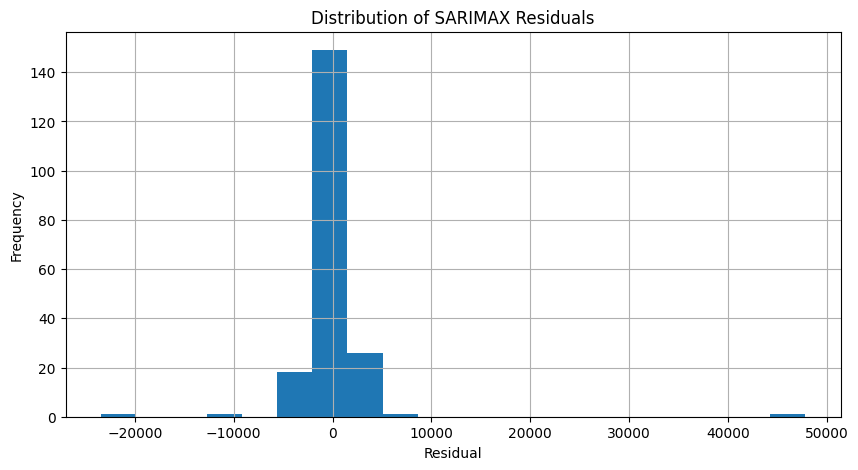

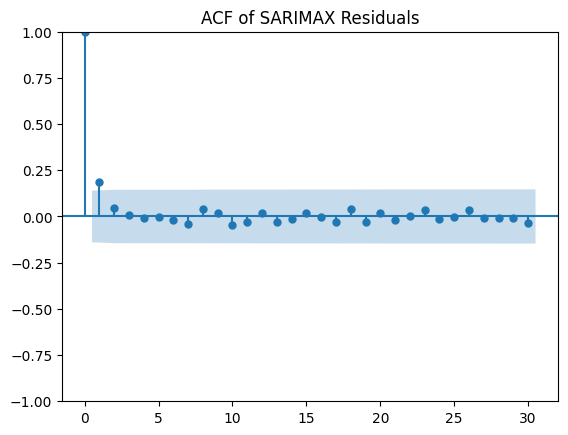

In [26]:
# Residual Diagnostics
from statsmodels.graphics.tsaplots import plot_acf

residuals = final_results.resid

print("="*60)
print("Residual Summary Statistics")
print("="*60)

print(residuals.describe())

# Histogram
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=20)
plt.title("Distribution of SARIMAX Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# ACF Plot
plot_acf(residuals, lags=30)
plt.title("ACF of SARIMAX Residuals")
plt.show()

## Compare Forecasting Models

This section compares the performance of the benchmark, SARIMA, and SARIMAX models using MAE, RMSE, and MAPE to identify the best forecasting approach.

In [27]:
# Model Comparison

import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "Seasonal Naive",
        "SARIMA",
        "SARIMAX"
    ],

    "MAE":[
        2318.52,
        2263.75,
        3265.97
    ],

    "RMSE":[
        3006.76,
        2883.07,
        4309.87
    ],

    "MAPE (%)":[
        4.41,
        4.32,
        6.31
    ]

})

print(comparison)

comparison

            Model      MAE     RMSE  MAPE (%)
0  Seasonal Naive  2318.52  3006.76      4.41
1          SARIMA  2263.75  2883.07      4.32
2         SARIMAX  3265.97  4309.87      6.31


,Model,MAE,RMSE,MAPE (%)
0,Seasonal Naive,2318.52,3006.76,4.41
1,SARIMA,2263.75,2883.07,4.32
2,SARIMAX,3265.97,4309.87,6.31


# Part 5: Machine Learning Models
## Create the Feature-Based Dataset

This section creates a feature-based dataset by combining electricity demand, temperature, calendar variables, lag features, and rolling statistics for machine learning models.

In [28]:
# Create Feature-Based Dataset

feature_data = weekly_data.copy()

# Add weekly temperature
feature_data["temperature"] = temperature_weekly["temperature"]

# Calendar features
feature_data["year"] = feature_data.index.year
feature_data["month"] = feature_data.index.month
feature_data["week"] = feature_data.index.isocalendar().week.astype(int)

# Lag features (previous electricity demand)
feature_data["lag_1"] = feature_data["load"].shift(1)
feature_data["lag_2"] = feature_data["load"].shift(2)
feature_data["lag_3"] = feature_data["load"].shift(3)
feature_data["lag_4"] = feature_data["load"].shift(4)

# Rolling statistics
feature_data["rolling_mean_4"] = (
    feature_data["load"]
    .shift(1)
    .rolling(window=4)
    .mean()
)

feature_data["rolling_std_4"] = (
    feature_data["load"]
    .shift(1)
    .rolling(window=4)
    .std()
)

print("="*60)
print("Feature Dataset")
print("="*60)

print("Shape:", feature_data.shape)

print("\nMissing Values:")
print(feature_data.isnull().sum())

print("\nFirst 5 Rows:")
display(feature_data.head())

Feature Dataset
Shape: (301, 11)

Missing Values:
load              0
temperature       0
year              0
month             0
week              0
lag_1             1
lag_2             2
lag_3             3
lag_4             4
rolling_mean_4    4
rolling_std_4     4
dtype: int64

First 5 Rows:


,load,temperature,year,month,week,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,rolling_std_4
timestamp,,,,,,,,,,,
2015-01-04,47233.739583,3.575000,2015,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-11,56191.101190,3.885714,2015,1,2,47233.739583,NaN,NaN,NaN,NaN,NaN
2015-01-18,57672.678571,4.900000,2015,1,3,56191.101190,47233.739583,NaN,NaN,NaN,NaN
2015-01-25,58613.303571,0.028571,2015,1,4,57672.678571,56191.101190,47233.739583,NaN,NaN,NaN
2015-02-01,58734.029762,1.414286,2015,2,5,58613.303571,57672.678571,56191.101190,47233.739583,54927.705729,5225.316274


## Clean the Feature Dataset

This section removes rows with missing values created during feature engineering to prepare the dataset for machine learning modelling.

In [29]:
# Clean Feature Dataset
# Remove rows with missing values

feature_data = feature_data.dropna()

print("="*60)
print("Clean Feature Dataset")
print("="*60)

print("Shape:", feature_data.shape)

print("\nMissing Values:")
print(feature_data.isnull().sum())

print("\nFirst 5 Rows:")
display(feature_data.head())

Clean Feature Dataset
Shape: (297, 11)

Missing Values:
load              0
temperature       0
year              0
month             0
week              0
lag_1             0
lag_2             0
lag_3             0
lag_4             0
rolling_mean_4    0
rolling_std_4     0
dtype: int64

First 5 Rows:


,load,temperature,year,month,week,lag_1,lag_2,lag_3,lag_4,rolling_mean_4,rolling_std_4
timestamp,,,,,,,,,,,
2015-02-01,58734.029762,1.414286,2015,2,5,58613.303571,57672.678571,56191.101190,47233.739583,54927.705729,5225.316274
2015-02-08,59323.898810,-1.228571,2015,2,6,58734.029762,58613.303571,57672.678571,56191.101190,57802.778274,1174.536724
2015-02-15,58137.779762,1.771429,2015,2,7,59323.898810,58734.029762,58613.303571,57672.678571,58585.977679,683.449334
2015-02-22,57802.898810,2.114286,2015,2,8,58137.779762,59323.898810,58734.029762,58613.303571,58702.252976,487.850835
2015-03-01,58862.452381,2.400000,2015,3,9,57802.898810,58137.779762,59323.898810,58734.029762,58499.651786,671.002301


## Prepare Training and Testing Data

This section splits the feature-based dataset into training and testing sets and separates the input features from the target variable for machine learning models.

In [30]:
# Train-Test Split for Feature-Based Models

# Last 104 weeks for testing
train_ml = feature_data.iloc[:-104]
test_ml = feature_data.iloc[-104:]

# Features
X_train = train_ml.drop(columns=["load"])
X_test = test_ml.drop(columns=["load"])

# Target
y_train = train_ml["load"]
y_test = test_ml["load"]

print("="*60)
print("Feature-Based Train-Test Split")
print("="*60)

print("Training Shape :", train_ml.shape)
print("Testing Shape  :", test_ml.shape)

print("\nTraining Period")
print(train_ml.index.min())
print(train_ml.index.max())

print("\nTesting Period")
print(test_ml.index.min())
print(test_ml.index.max())

print("\nFeature Columns:")
print(list(X_train.columns))

Feature-Based Train-Test Split
Training Shape : (193, 11)
Testing Shape  : (104, 11)

Training Period
2015-02-01 00:00:00
2018-10-07 00:00:00

Testing Period
2018-10-14 00:00:00
2020-10-04 00:00:00

Feature Columns:
['temperature', 'year', 'month', 'week', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'rolling_mean_4', 'rolling_std_4']


## Train the Random Forest Model

This section trains a Random Forest Regressor using the engineered features to predict weekly electricity demand.

In [31]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

print("="*60)
print("Training Random Forest Regressor")
print("="*60)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Successfully Trained!")

Training Random Forest Regressor
Random Forest Model Successfully Trained!


## Evaluate the Random Forest Model

This section evaluates the forecasting performance of the Random Forest model using MAE, RMSE, and MAPE.

In [32]:
# Evaluate Random Forest

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

rf_forecast = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_forecast)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_forecast))
rf_mape = mean_absolute_percentage_error(y_test, rf_forecast) * 100

print("="*60)
print("Random Forest Performance")
print("="*60)

print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"MAPE : {rf_mape:.2f}%")

Random Forest Performance
MAE  : 1813.08
RMSE : 2428.98
MAPE : 3.43%


## Train the Gradient Boosting Model

This section trains a Gradient Boosting Regressor using the engineered features to predict weekly electricity demand.

In [33]:
# Train Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor

print("="*60)
print("Training Gradient Boosting Regressor")
print("="*60)

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Successfully Trained!")

Training Gradient Boosting Regressor
Gradient Boosting Model Successfully Trained!


## Evaluate the Gradient Boosting Model

This section evaluates the forecasting performance of the Gradient Boosting model using MAE, RMSE, and MAPE.

In [34]:
# Evaluate Gradient Boosting

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

gb_forecast = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_forecast)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_forecast))
gb_mape = mean_absolute_percentage_error(y_test, gb_forecast) * 100

print("="*60)
print("Gradient Boosting Performance")
print("="*60)

print(f"MAE  : {gb_mae:.2f}")
print(f"RMSE : {gb_rmse:.2f}")
print(f"MAPE : {gb_mape:.2f}%")

Gradient Boosting Performance
MAE  : 1902.66
RMSE : 2477.98
MAPE : 3.61%


## Compare Feature-Based Model Forecasts

This section compares the forecasts produced by the Random Forest and Gradient Boosting models against the actual electricity demand over the testing period.

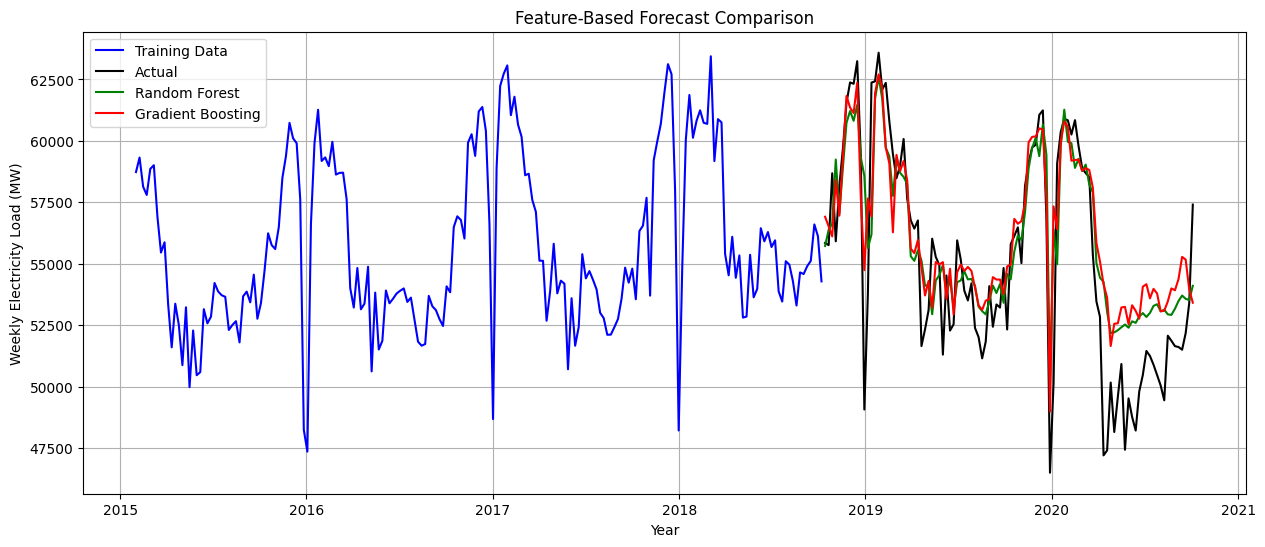

In [35]:
# Forecast Comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_train.index, y_train, label="Training Data", color="blue")
plt.plot(y_test.index, y_test, label="Actual", color="black")
plt.plot(y_test.index, rf_forecast, label="Random Forest", color="green")
plt.plot(y_test.index, gb_forecast, label="Gradient Boosting", color="red")

plt.title("Feature-Based Forecast Comparison")
plt.xlabel("Year")
plt.ylabel("Weekly Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.show()

# Part 6: Deep Learning (LSTM)
## Prepare the Hourly Dataset for LSTM

This section prepares the hourly electricity demand dataset for LSTM modelling and verifies its structure and data quality.

In [37]:
# Prepare Hourly Data for LSTM

print("="*60)
print("Preparing Hourly Dataset for LSTM")
print("="*60)

# Use the hourly electricity load
lstm_data = hourly_data[['load']].copy()

print("Shape :", lstm_data.shape)

print("\nMissing Values:")
print(lstm_data.isnull().sum())

print("\nFirst 5 Rows:")
display(lstm_data.head())

print("\nLast 5 Rows:")
display(lstm_data.tail())

Preparing Hourly Dataset for LSTM
Shape : (50400, 1)

Missing Values:
load    0
dtype: int64

First 5 Rows:


,load
timestamp,
2015-01-01 00:00:00+00:00,41151.0
2015-01-01 01:00:00+00:00,40135.0
2015-01-01 02:00:00+00:00,39106.0
2015-01-01 03:00:00+00:00,38765.0
2015-01-01 04:00:00+00:00,38941.0



Last 5 Rows:


,load
timestamp,
2020-09-30 19:00:00+00:00,57559.0
2020-09-30 20:00:00+00:00,54108.0
2020-09-30 21:00:00+00:00,49845.0
2020-09-30 22:00:00+00:00,46886.0
2020-09-30 23:00:00+00:00,45461.0


## Scale the Hourly Data

This section scales the hourly electricity demand data to a range of 0–1, making it suitable for training the LSTM model.

In [38]:
# Scale the Hourly Data

from sklearn.preprocessing import MinMaxScaler

print("="*60)
print("Scaling Hourly Electricity Load")
print("="*60)

# Scale between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(lstm_data)

print("Scaled Data Shape:", scaled_data.shape)

print("\nFirst 5 Scaled Values:")
print(scaled_data[:5])

print("\nMinimum:", scaled_data.min())
print("Maximum:", scaled_data.max())

Scaling Hourly Electricity Load
Scaled Data Shape: (50400, 1)

First 5 Scaled Values:
[[0.21288007]
 [0.1909087 ]
 [0.1686562 ]
 [0.16128195]
 [0.16508802]]

Minimum: 0.0
Maximum: 1.0


## Create LSTM Input Sequences

This section creates input sequences and target values from the scaled data, preparing the dataset for LSTM training.

In [39]:
# Create LSTM Sequences

import numpy as np

print("="*60)
print("Creating LSTM Sequences")
print("="*60)

sequence_length = 24

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Input Shape (X):", X.shape)
print("Target Shape (y):", y.shape)

print("\nExample Input Sequence Shape:")
print(X[0].shape)

print("\nFirst Target Value:")
print(y[0])

Creating LSTM Sequences
Input Shape (X): (50376, 24, 1)
Target Shape (y): (50376,)

Example Input Sequence Shape:
(24, 1)

First Target Value:
0.20046710782405608


## Split the LSTM Training and Testing Data

This section splits the LSTM sequences into training and testing sets, reserving the final two years of hourly data for model evaluation.

In [40]:
# Train-Test Split for LSTM

print("="*60)
print("LSTM Train-Test Split")
print("="*60)

# Last 2 years (hourly)
test_size = 24 * 365 * 2  # 17,520 hours

X_train = X[:-test_size]
X_test = X[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

print("\nTarget Training Shape :", y_train.shape)
print("Target Testing Shape  :", y_test.shape)

LSTM Train-Test Split
Training Samples : (32856, 24, 1)
Testing Samples  : (17520, 24, 1)

Target Training Shape : (32856,)
Target Testing Shape  : (17520,)


## Build the LSTM Model

This section builds and compiles the LSTM model using stacked LSTM layers and dropout to learn patterns in the hourly electricity demand data.

In [41]:
# Build LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("="*60)
print("Building LSTM Model")
print("="*60)

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

model.summary()

Building LSTM Model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 24, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model

This section trains the LSTM model using the training data and applies early stopping to reduce overfitting and improve generalisation.

In [42]:
# Train LSTM Model

from tensorflow.keras.callbacks import EarlyStopping

print("="*60)
print("Training LSTM Model")
print("="*60)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM Model
Epoch 1/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 0.0255 - val_loss: 0.0081
Epoch 2/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0086 - val_loss: 0.0030
Epoch 3/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0054 - val_loss: 0.0024
Epoch 4/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0042 - val_loss: 0.0012
Epoch 5/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0034 - val_loss: 0.0010
Epoch 6/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - loss: 0.0028 - val_loss: 8.5366e-04
Epoch 7/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0024 - val_loss: 9.5702e-04
Epoch 8/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0021 - val_loss: 7.7708e-04
Epoch 9/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0018 - val_loss: 7.6870e-04
Epoch 10/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.0017 - val_loss: 7.3363e-04
Epoch 11/20
411/411 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0016 - val_loss: 6.8519

## Visualise the LSTM Training History

This section visualises the training and validation loss across epochs to assess the learning progress and detect potential overfitting.

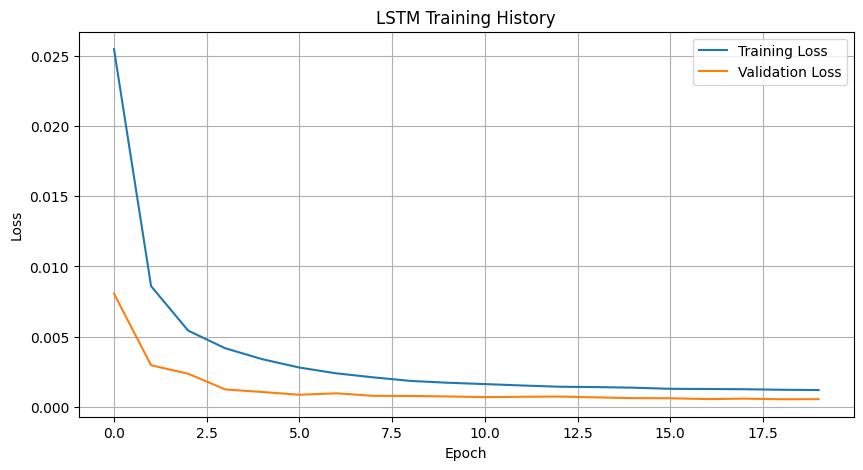

In [43]:
# Plot Training History

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

## Generate LSTM Forecast

This section uses the trained LSTM model to generate forecasts for the testing dataset and produces the predicted electricity demand values.

In [44]:
# Generate LSTM Forecast

print("="*60)
print("Generating LSTM Forecast")
print("="*60)

# Predict on test data
predictions = model.predict(X_test)

print("Prediction Shape:", predictions.shape)

print("\nFirst 5 Predictions (Scaled):")
print(predictions[:5])

Generating LSTM Forecast
548/548 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
Prediction Shape: (17520, 1)

First 5 Predictions (Scaled):
[[0.30815288]
 [0.28929475]
 [0.36782482]
 [0.42713404]
 [0.58510566]]


## Convert Predictions to the Original Scale

This section converts the scaled LSTM predictions and actual values back to their original electricity demand values (MW) for evaluation and comparison.

In [45]:
# Convert Predictions Back to Original Scale

print("="*60)
print("Converting Predictions to Original Scale")
print("="*60)

# Convert predictions back to MW
predictions = scaler.inverse_transform(predictions)

# Convert actual values back to MW
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

print("Prediction Shape :", predictions.shape)
print("Actual Shape     :", y_test_actual.shape)

print("\nFirst 5 Predictions (MW)")
print(predictions[:5])

print("\nFirst 5 Actual Values (MW)")
print(y_test_actual[:5])

Converting Predictions to Original Scale
Prediction Shape : (17520, 1)
Actual Shape     : (17520, 1)

First 5 Predictions (MW)
[[45556.605]
 [44684.57 ]
 [48315.953]
 [51058.53 ]
 [58363.453]]

First 5 Actual Values (MW)
[[44899.]
 [45550.]
 [47150.]
 [51794.]
 [59531.]]


## Evaluate the LSTM Model

This section evaluates the forecasting performance of the LSTM model using MAE, RMSE, and MAPE.

In [46]:
# Evaluate LSTM Model

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

lstm_mae = mean_absolute_error(y_test_actual, predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
lstm_mape = mean_absolute_percentage_error(y_test_actual, predictions) * 100

print("="*60)
print("LSTM Performance")
print("="*60)

print(f"MAE  : {lstm_mae:.2f}")
print(f"RMSE : {lstm_rmse:.2f}")
print(f"MAPE : {lstm_mape:.2f}%")

LSTM Performance
MAE  : 812.78
RMSE : 1091.41
MAPE : 1.53%


## Visualise the LSTM Forecast

This section compares the LSTM forecast with the actual electricity demand to evaluate the model's prediction accuracy on the testing dataset.

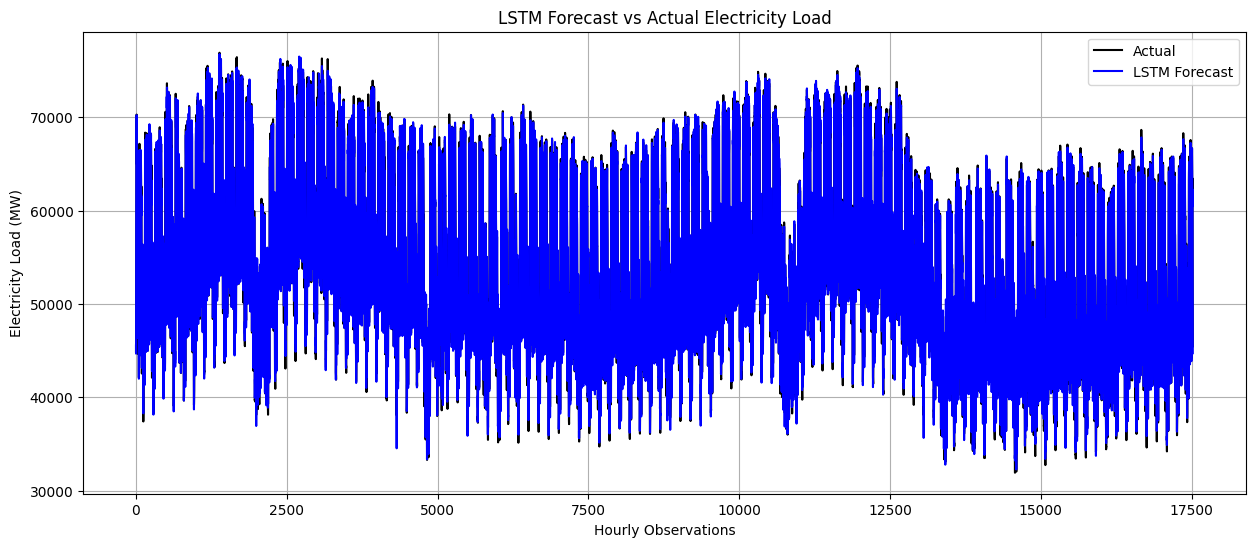

In [47]:
# LSTM Forecast Plot

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(y_test_actual, label="Actual", color="black")
plt.plot(predictions, label="LSTM Forecast", color="blue")

plt.title("LSTM Forecast vs Actual Electricity Load")
plt.xlabel("Hourly Observations")
plt.ylabel("Electricity Load (MW)")
plt.legend()
plt.grid(True)

plt.show()